# Продвинутый анализ моделей


|раздел | [nixtla](https://nixtlaverse.nixtla.io/statsforecast/) | [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|

https://otexts.com/fpppy/nbs/13-practical.html

## Импорт

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [3]:
from scipy import stats
import pmdarima as pm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss

import statsmodels.api as sm

In [4]:
from pandas.tseries.frequencies import to_offset

In [5]:
from TSC_Nixtla_dump import *
plt_style_GOST()

In [6]:
from TSC_Nixtla_augmentation import *

In [7]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [8]:
from functools import partial

## Загрузка данных

Импорт данных аналогично предыдущего урока.

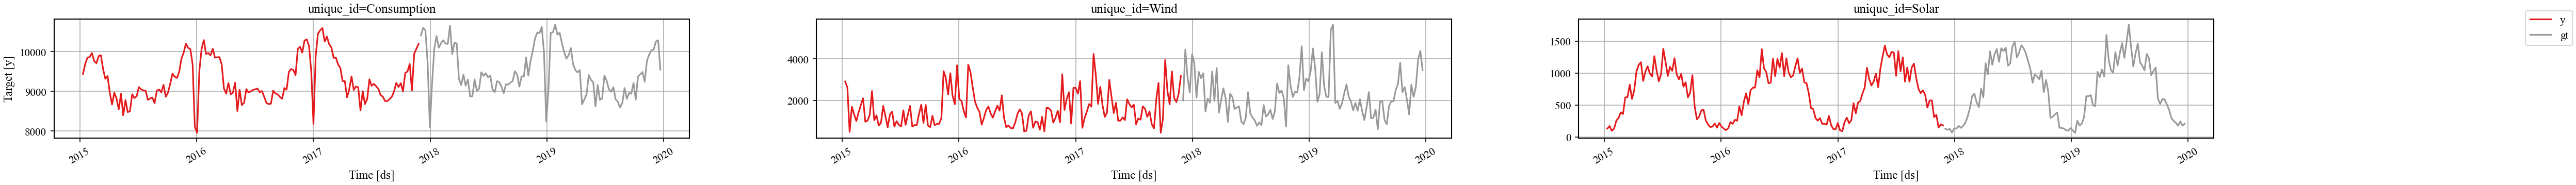

In [9]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 3)

In [10]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    'CPSR':scaled_crps,
    'CI':coverage,
    'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Некоторые приемы аугментации данных

### Backcasting

In [11]:
BH = 3*SEASON
LEVEL = [90]
models = [
    ARIMA(order=(2, 1, 1), season_length=SEASON, seasonal_order=(0, 1, 1))
]

df_train_extended = backcast(
    df_train=df_train,
    models=models,
    h=BH,
    freq=FREQ,
    level=LEVEL
)

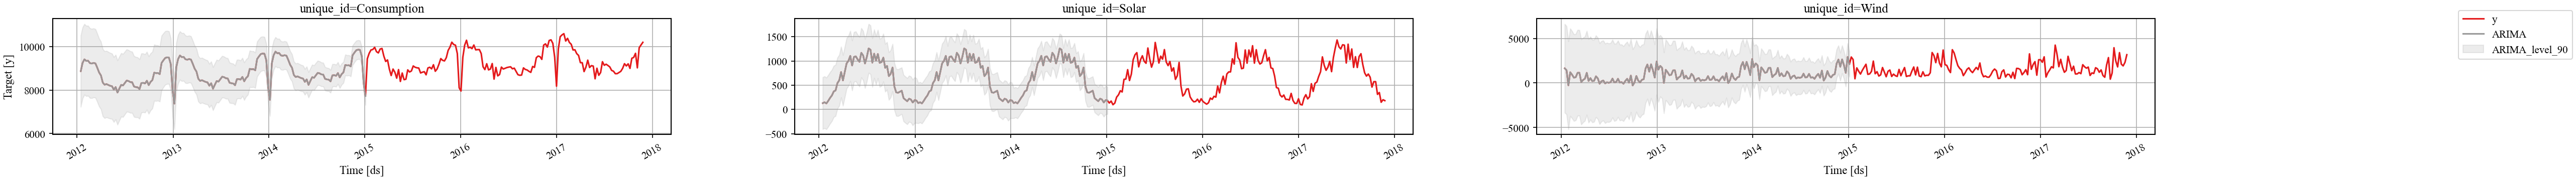

In [12]:
plot_series_v2( forecasts_df=df_train_extended, level=LEVEL[-1:],  palette='Set1', n_cols = 3)

#### Сравнение методов с и без расширения

##### С расширением  `backcast`

In [13]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    # MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),   
]

LEVELS = [90]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)
aliases = [model.alias for model in models]

In [14]:
fcst_sf = sf.forecast(df=df_train_extended, h=FH, level=LEVELS,)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train_extended,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)


metrics_sf_models = pd.concat({'with_backcast': metrics_sf_models}, axis=1)

metrics_sf_models.style.format('{:.2f}')

##### Без расширения

In [15]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS,)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models_ = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)

##### Сравним 2 модели по метрикам

In [16]:
metrics_sf_models_ = pd.concat({'GT': metrics_sf_models_}, axis=1)

metrics_sf_models = pd.concat([metrics_sf_models_, metrics_sf_models], axis=1)

metrics_sf_models.style.format('{:.2f}')

Результаты показывают некоторое снижение точеченых метрик при увеличении неопределенности прогноза. Хотя, при этом 95 и 5 хвосты предсказываются чуть лучше. coverage_level90 показывает ухудшение оценки интервалов.

#### Провека адекватности аугментации
##### Сравнения маргинальных распределений

Проверка адекватности аугментации начинается с сравнения маргинальных распределений исходного и синтетического рядов (без учета времени): если они статистически близки, аугментация не искажает базовые свойства данных.

* __нормализованное Wasserstein distance__ - сводная статистика, учиюывающая  форму, и сдвиг, измеряется в тех же единицах, что и данные.  Нормализация проводится к СКО. Интерпретация, если различия распределений сопостовимы с СКО, то имеют место существенные систематическом изменения в распределениях. 
* __KS statistic__ — сводная статистика Калмогорова-Смирнова для 2 двух распределений, учиюывающая максимальную (локальную) разницу параметров в гистограммах двух распределений. 
* __относительня mean_diff_pct__  — показывает смещение центра распределения (систематическое смещение).
* ____относительня std_diff_pct__ — показывает изменение разброса данных (систематическое изменение разброса данных).

Отметим, что лучше проводить тесты после учета тренда и сезонности.

In [17]:
n_backcast = len(df_train_extended) - len(df_train)
result = marginal_distribution_test(df_train['y'].values, df_train_extended.iloc[:n_backcast]['y'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,wasserstein,0.5901,0.1500,0
1,backcasting,ks_pvalue,0.0000,0.0500,0
2,backcasting,mean_diff_pct,59.4731,5.0000,0
3,backcasting,std_diff_pct,2.6514,10.0000,1


Результаты показывают что модель беккастинга воспроизводит только СКО оригинального ряда

##### Сравнение остатков

Отметим, что лучше проводить тесты после учета тренда и сезонности.

In [18]:
from statsforecast.feature_engineering import mstl_decomposition


mstl_model =  MSTL(season_length=[SEASON])

transformed_df, _ = mstl_decomposition(
    df_train,
    model=mstl_model,
    freq=FREQ,
    h=1  # h=0 если только хотим декомпозицию
)
transformed_df['residual'] = transformed_df['y']  - transformed_df['trend'] - transformed_df['seasonal'] 


transformed_df_extend, _ = mstl_decomposition(
    df_train_extended,
    model=mstl_model,
    freq=FREQ,
    h=1  # h=0 если только хотим декомпозицию
)
transformed_df_extend['residual'] = transformed_df_extend['y']  - transformed_df_extend['trend'] - transformed_df_extend['seasonal'] 

n_backcast = len(transformed_df_extend) - len(transformed_df)
result = marginal_distribution_test(transformed_df['residual'].values, transformed_df_extend.iloc[:n_backcast]['residual'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,wasserstein,0.4981,0.1500,0
1,backcasting,ks_pvalue,0.0000,0.0500,0
2,backcasting,mean_diff_pct,329.3915,5.0000,0
3,backcasting,std_diff_pct,72.9276,10.0000,0


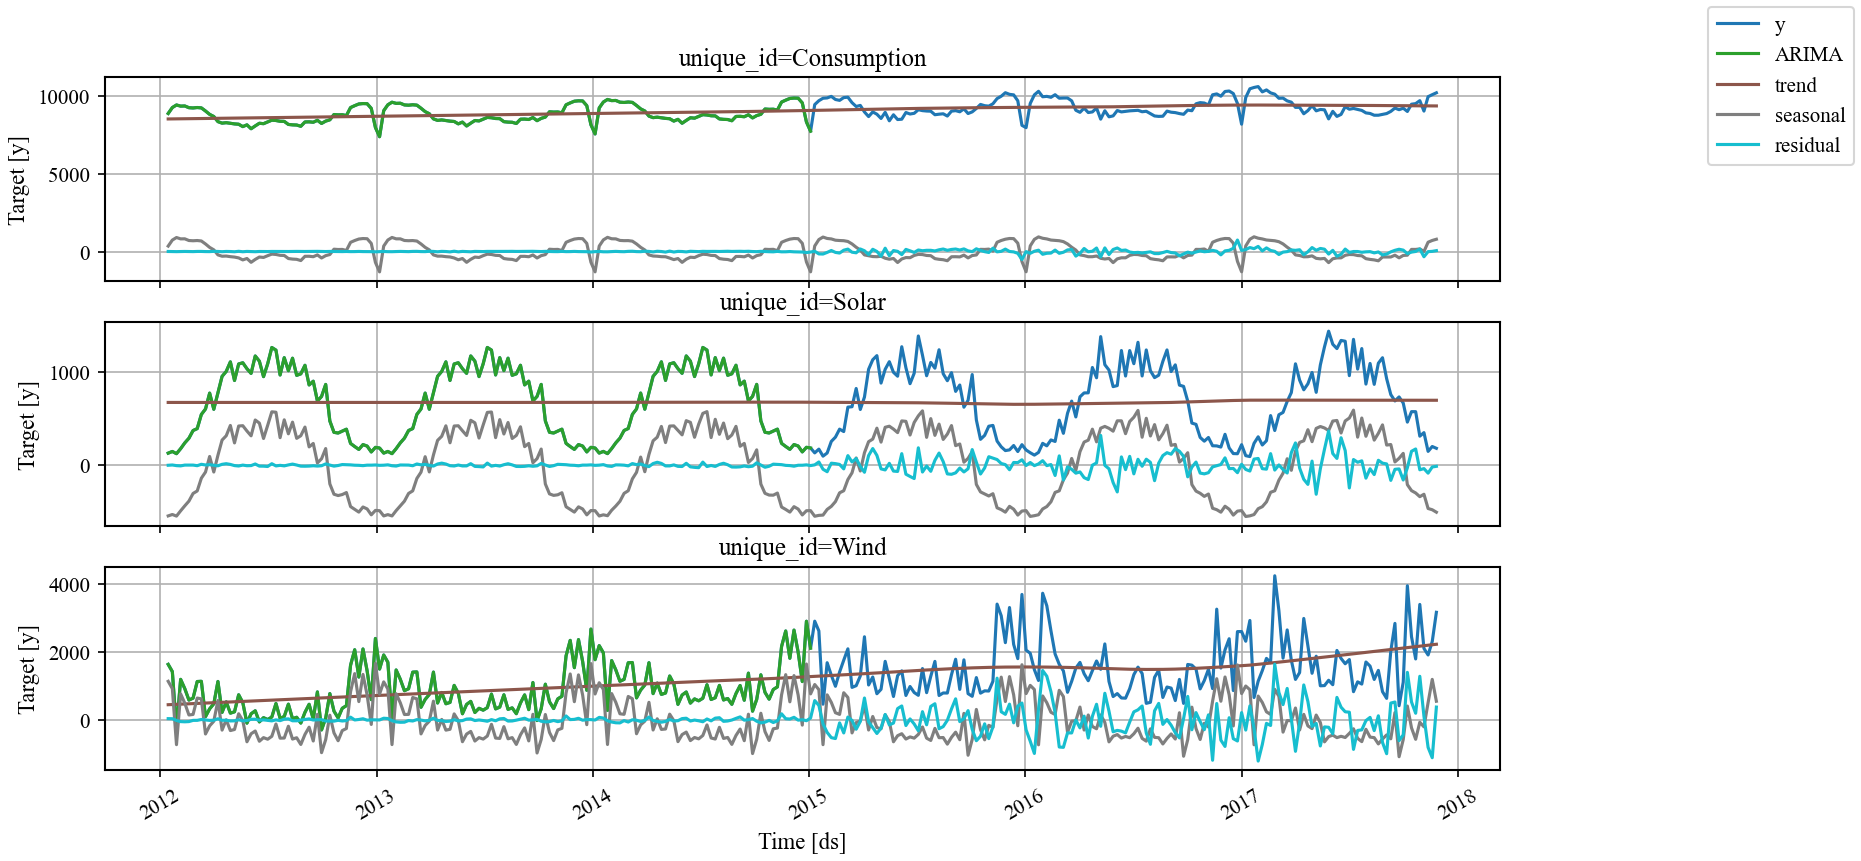

In [19]:
plot_series_v2(forecasts_df=transformed_df_extend)

Видно, что действительно тренд и остатки поменял форм.

##### Структурные тесты

Также проведем тесты 

* __ACF MAE__  — средняя ошибка между ACF оригинала и аугментации (проверяет сохранение временной структуры).
* __Spectral distance__ — расстояние Вассерштейна между спектрами мощности (проверяет сезонность).
* __Quantile coverage__  — сохаранение значений покрытия ключевых квантилей (10%, 50%, 90%).
* __Volatility correlation__ — корреляция скользящего стандартного отклонения (проверяет кластеризацию волатильности).

In [20]:
n_backcast = len(df_train_extended) - len(df_train)
result = structural_tests(df_train['y'].values, df_train_extended.iloc[:n_backcast]['y'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,acf_mae,0.0087,0.0500,1
1,backcasting,spectral_dist,0.0017,0.2000,1
2,backcasting,quantile_max_diff,1.8127,0.1500,0
3,backcasting,volatility_corr,0.1937,0.7000,0


In [21]:
n_backcast = len(df_train_extended) - len(df_train)
result = structural_tests(transformed_df['residual'].values, transformed_df_extend.iloc[:n_backcast]['residual'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,acf_mae,0.0878,0.0500,0
1,backcasting,spectral_dist,0.0453,0.2000,1
2,backcasting,quantile_max_diff,0.8187,0.1500,0
3,backcasting,volatility_corr,-0.4687,0.7000,0


Видно сохранение сезонной составляющей (ACF  и spectral_dist для обоих ВР), однако ни покрытие интервалов, ни гетероскедастичность не сохраняются

#### Упражение 
1. провести настройку  и  сравнение  различных методов для backcasting и их виляния на метрики
2. Провести анализ остатков предсказания с беккастингом и без него
3. Проведите backtesing (CV) с backcasting и без

### Стресс-тесты / аугментация искажениями

#### Примеры искажений

Кроме расширения выборки также может быть использована аугментация путем искажений - создания искусственных нерегулярностей в данных.

Примеры приведены ниже

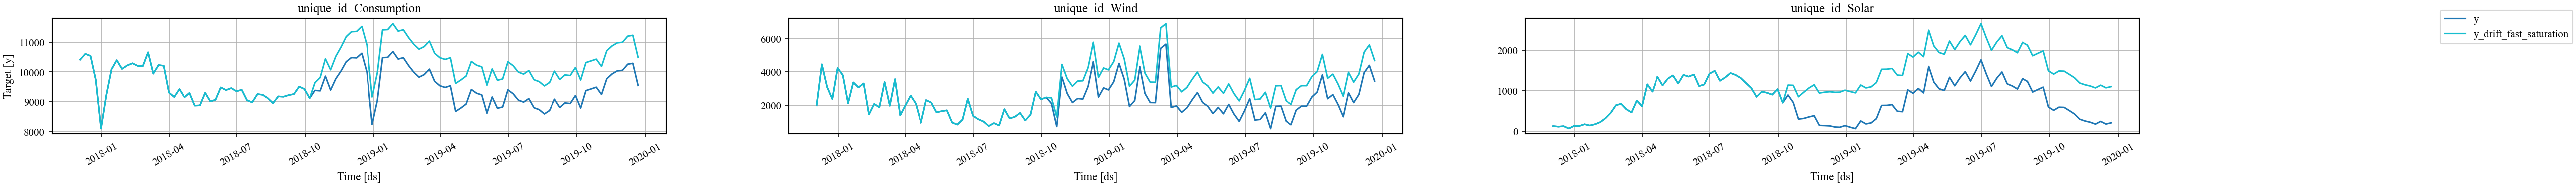

In [22]:
df_structural_shift = add_structural_shift_by_iqr(
    df_test.copy(), 
    start_date='2018-10-01', 
    shift_percent=100, 
    strategy='fast_saturation', 
    duration_offset='26W',
    freq=FREQ
)

plot_series_v2(forecasts_df=df_structural_shift, n_cols = 3)

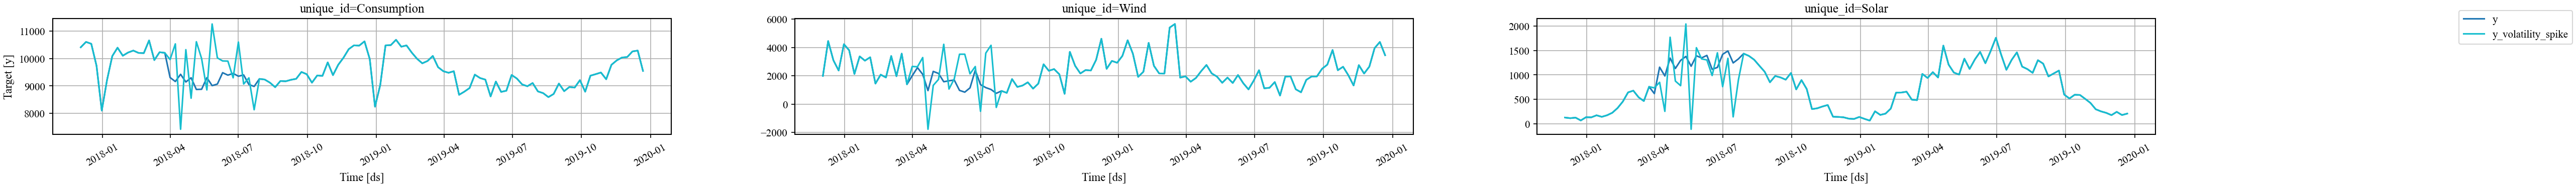

In [23]:
df_spike = add_local_volatility_spike(
    df_test,
    spike_start='2018-04-01',
    duration_offset='16W',
    noise_percent=50.0,
    freq=FREQ
)

plot_series_v2(forecasts_df=df_spike, n_cols = 3)

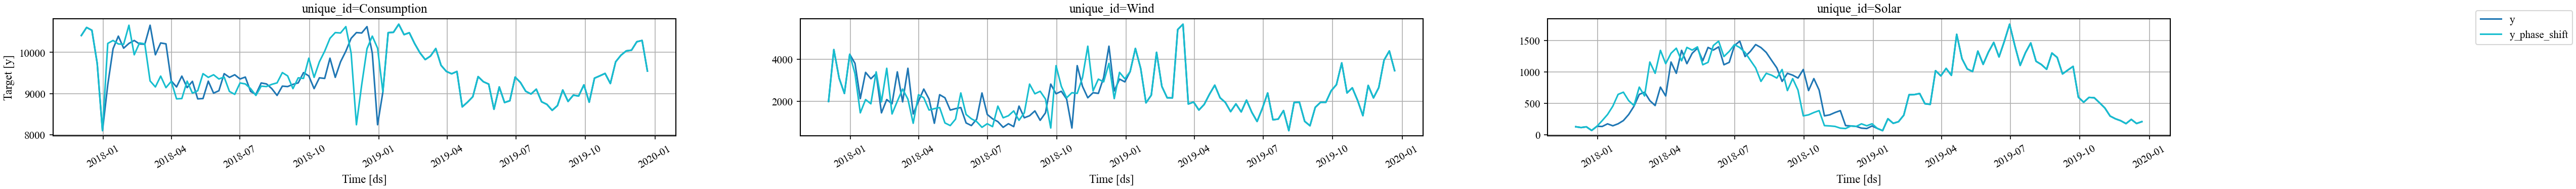

In [24]:
df_seasonal_shift = add_seasonal_phase_shift(
    df_test,
    phase_shift_steps=4,
    season_length=SEASON,          # используется только для документации
    start_date='2018-01-01',
    duration_offset='1Y',
    freq=FREQ
)

plot_series_v2( forecasts_df=df_seasonal_shift, n_cols = 3)

#### Оценка с искажениями

In [36]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS,)

eval_sf = df_spike.merge(fcst_sf, on=['unique_id', 'ds'])
eval_sf['y'] = eval_sf['y_volatility_spike']

metrics_sf_models_ = evaluate(
    df=eval_sf,
    metrics=metrics,
    models = ['ETS'],
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)
metrics_sf_models_ = pd.concat({'seasonal_shift': metrics_sf_models_}, axis=1)

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    models = ['ETS'],
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)
metrics_sf_models = pd.concat({'GT': metrics_sf_models}, axis=1)

metrics_sf_models = pd.concat([metrics_sf_models, metrics_sf_models_], axis=1)

metrics_sf_models.style.format('{:.2f}')


- Consumption и Solar стали менее надёжными в оценке неопределённости, особенно на хвостах распределения.
- Wind значительно устойчивей остальных  — возможно, делов в присущей значительно волатильности параметра.
- Модели чувствительны к фазовому сдвигу сезонности — особенно ETS, который явно полагается на жёсткую сезонную структуру.

#### Упражнения №1
1. проверить разные комибнации аугменатций
2. проверить точность с комформным преобразованием
3. проверить точность с бектестинг

#### Упражнения №2 
1. Проверить влияние эффектов аугментации для ВР с шагом в 1 день.

## Тюнинг

### Ансамблирование моделей

#### Выбор моделей для ансамбля

 модели со встроенной оценкой неопределенности

In [76]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    AutoETS(season_length=SEASON, model='MNA', damped = False, alias='SesSES'),
    MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),
    # ARIMA(order=(3, 1, 1),
    #             season_length = SEASON,
    #             seasonal_order = (0, 1, 1,)  )
    
]
aliases = [model.alias for model in models]
LEVELS  = [90, 95]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

проверка работы моделей по отдельности

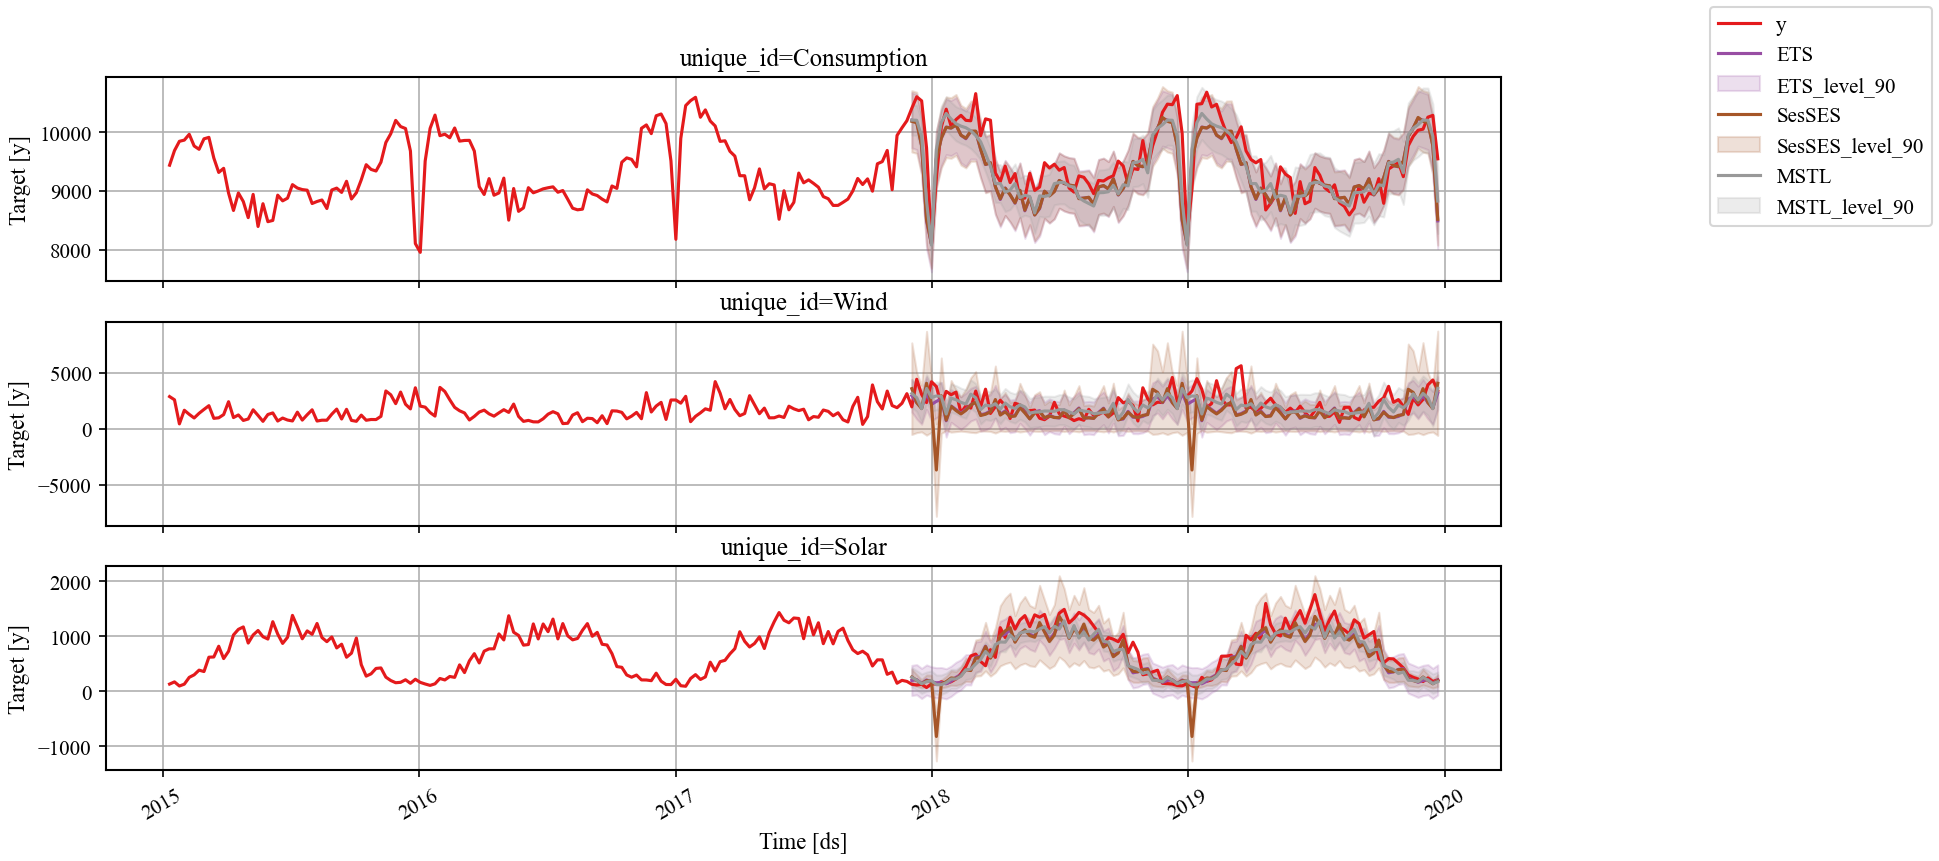

In [77]:
fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS
                     )

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics = metrics,
    models  = aliases,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[:1],
    palette='Set1',
)

####  Навиный Анcамбль
##### Ансамбль средних

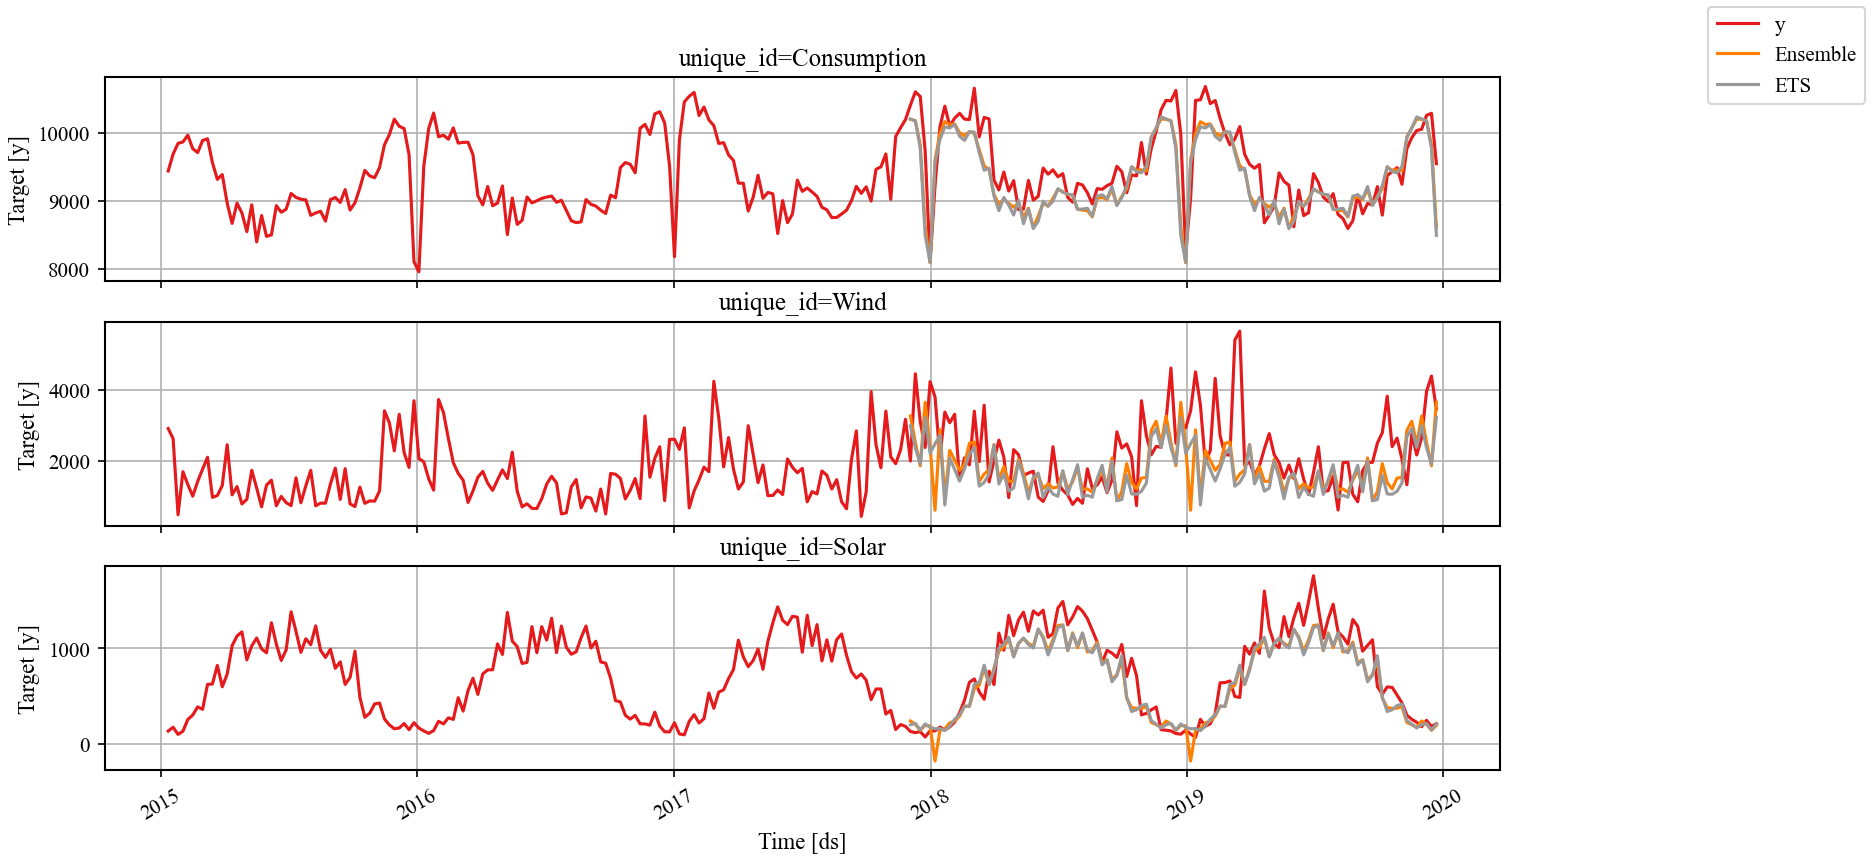

In [78]:
fcst_sf['Ensemble'] = fcst_sf[aliases].mean(axis=1)


# Объединяем с тестом
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

# Визуализация
plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    models=['Ensemble',  aliases[0]],  # покажем сравнение
    # level=[90],
    palette='Set1',
)

##### Метрики

In [79]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics[:3],
    train_df=df_train,
    # level=LEVELS[-1:],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'Ensemble']
)
metrics_sf_models.style.format('{:.2f}')

Как и ожидалось пдобный ансамбль лучше худших, но не лучше лучшего

##### Добавим интревалы наивным образом

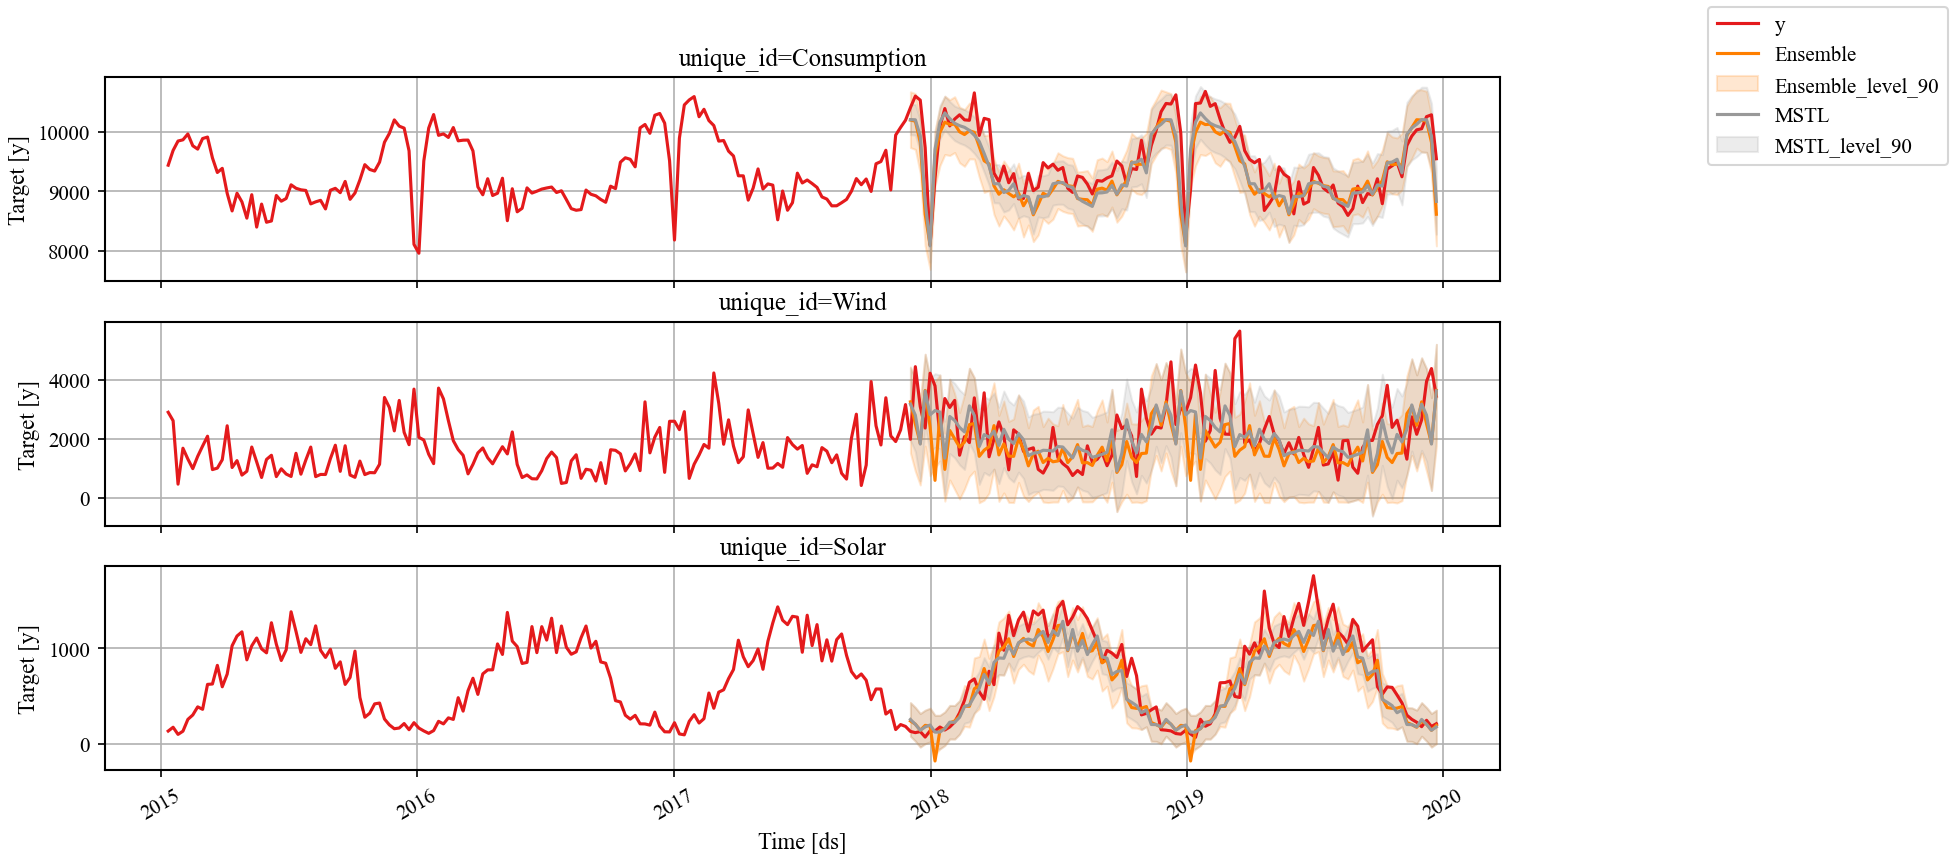

In [80]:
lvl  = LEVELS[:1][0]


lo_cols = [f"{name}-lo-{lvl}" for name in aliases if f"{name}-lo-{lvl}" in fcst_sf.columns]
hi_cols = [f"{name}-hi-{lvl}" for name in aliases if f"{name}-hi-{lvl}" in fcst_sf.columns]


fcst_sf[f'Ensemble-lo-{lvl}'] = fcst_sf[lo_cols].median(axis=1)
fcst_sf[f'Ensemble-hi-{lvl}'] = fcst_sf[hi_cols].median(axis=1)


eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])
  
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'Ensemble']
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    models=['Ensemble',  aliases[-1]],  # покажем сравнение
    level=LEVELS[:1],
    palette='Set1',
)

покрытие интервалов ведет себя точно также

#### Упражнение
1. проверить устойчивость ансамбля
2. проверить возможность добавления новых участников в ансамбль

### Взвешенный ансамбль

#### Квантильное взвешивание

Простое усреднение прогнозов не учитывает различия в качестве моделей и может ухудшать результат по сравнению с лучшей моделью (например, ARIMA показывала меньшую ошибку, чем невзвешенный ансамбль). Это связано с тем, что усреднение игнорирует вклад каждой модели в оценку неопределённости.

Одно из решений — использовать взвешенный ансамбль, где вес $ w_m $ модели $ m $ обратно пропорционален её ошибке. Наилучшей мерой ошибки для квантильных прогнозов является квантильный Loss.

Для квантиля уровня $ \alpha \in (0,1) $ вес модели определяется как:
$$
w_{m,\alpha} = \frac{1 / \left( \text{PL}_m(\alpha) + \varepsilon \right)}{\sum_{k=1}^M 1 / \left( \text{PL}_k(\alpha) + \varepsilon \right)},
$$
где $ \text{PL}_m(\alpha) = \frac{1}{N} \sum_{t=1}^N \ell_\alpha(y_t, \hat{q}_{t,\alpha}^{(m)}) $ — среднее значенвие квантильного Loss модели $ m $,  
$ \ell_\alpha(y, \hat{q}) = (y - \hat{q})(\alpha - \mathbb{I}\{y < \hat{q}\}) $ значенвие квантильного Loss модели $ m $ для квантиля $q$,  
а $ \varepsilon > 0 $ — малая константа для численной устойчивости.

Ансамблевый прогноз:
$$
\hat{q}_{t,\alpha}^{\text{ens}} = \sum_{m=1}^M w_{m,\alpha} \cdot \hat{q}_{t,\alpha}^{(m)}.
$$

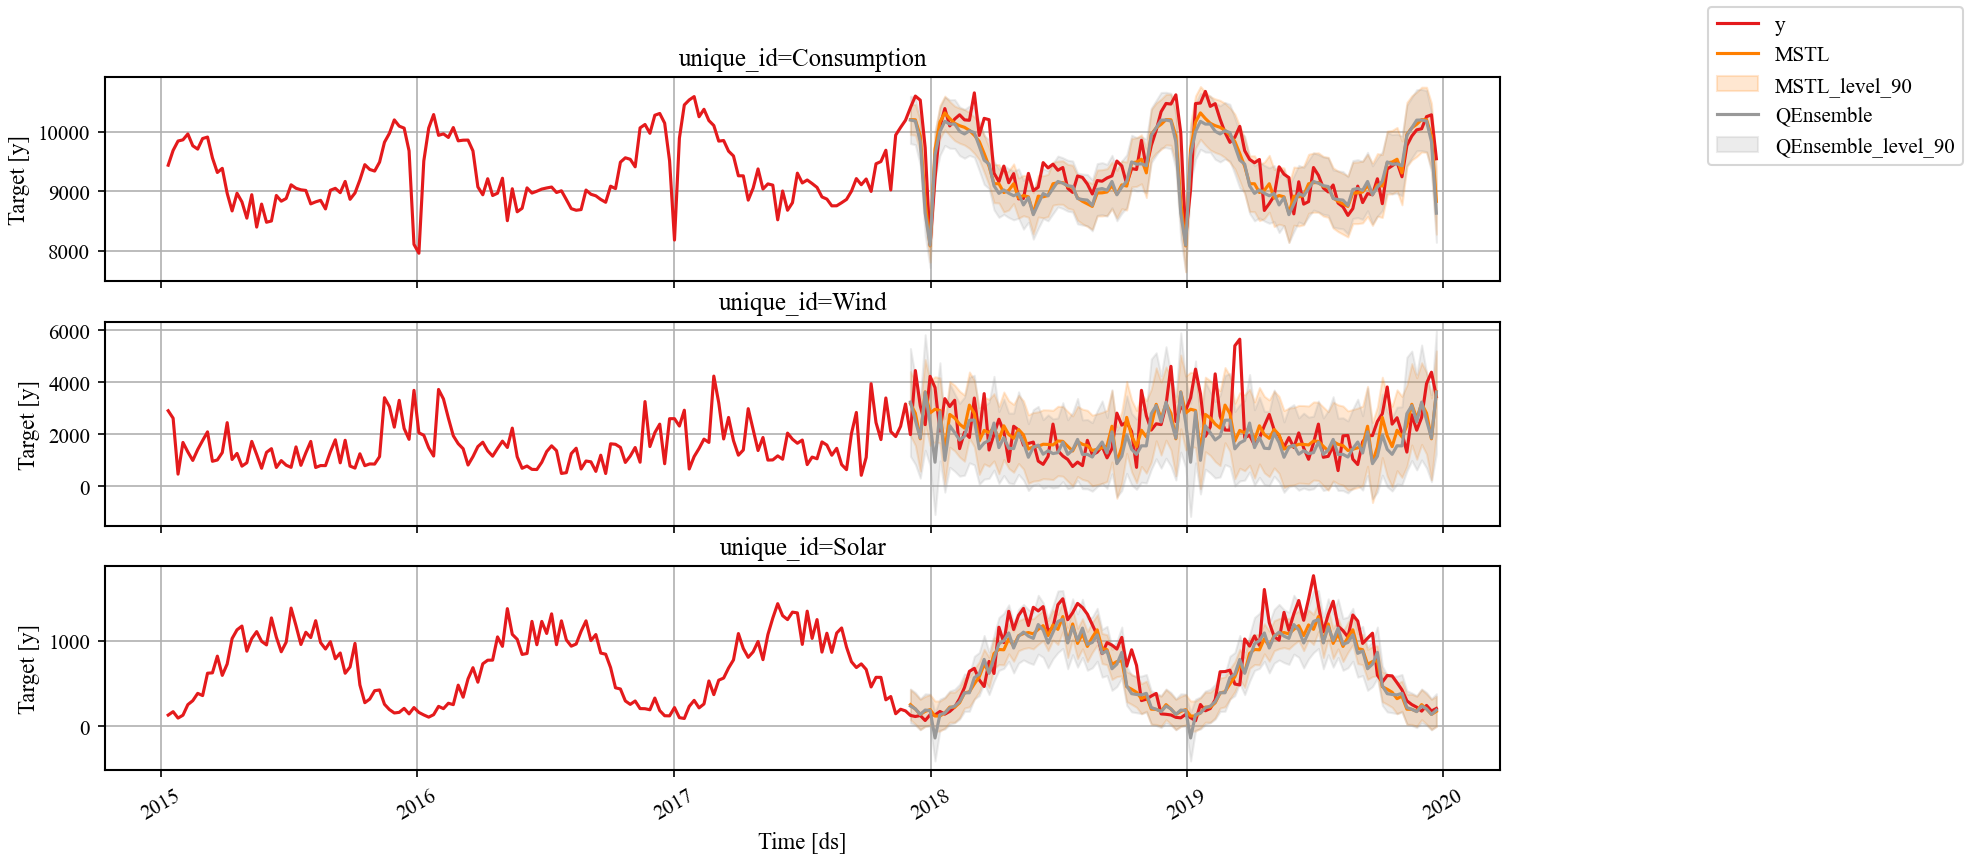

In [85]:
fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS
                     )
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

fcst_qensemble = quantile_ensemble_forecast(
    eval_df=eval_sf,
    model_names=aliases,
    levels=LEVELS,           
    target_col='y'
)
eval_sf = eval_sf.merge(fcst_qensemble, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'QEnsemble']
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    models=['MSTL','QEnsemble'],
    level=LEVELS[:1],
    palette='Set1'
)

Полученный ансамбль слегка лучше.

#### Получим веса по метрикам

Можно построить ансамбли для различных метрик, которые мы используем. Получим их названия

In [93]:
metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=[90])
metrics_df['metric'].unique()

array(['mase', 'mae', 'rmse', 'smape', 'scaled_crps', 'coverage_level90',
       'scaled_quantile_loss_q0.05', 'scaled_quantile_loss_q0.95'],
      dtype=object)

Проверим, что для разных метрик разные веса

In [111]:
weight_dict = ensemble_weights_from_metrics(
    metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=LEVELS[:1]),
    aliases=aliases,
    metric_name = 'scaled_crps',
    per_series = False,
)
weight_dict

{'ETS': 0.3481494628989998,
 'SesSES': 0.27467597464191207,
 'MSTL': 0.3771745624590881}

#### Построение ансамбля с весами

In [116]:
weight_dict_ = {'ETS': 0.05,
               'SesSES': 0.05,
               'MSTL': 0.9}

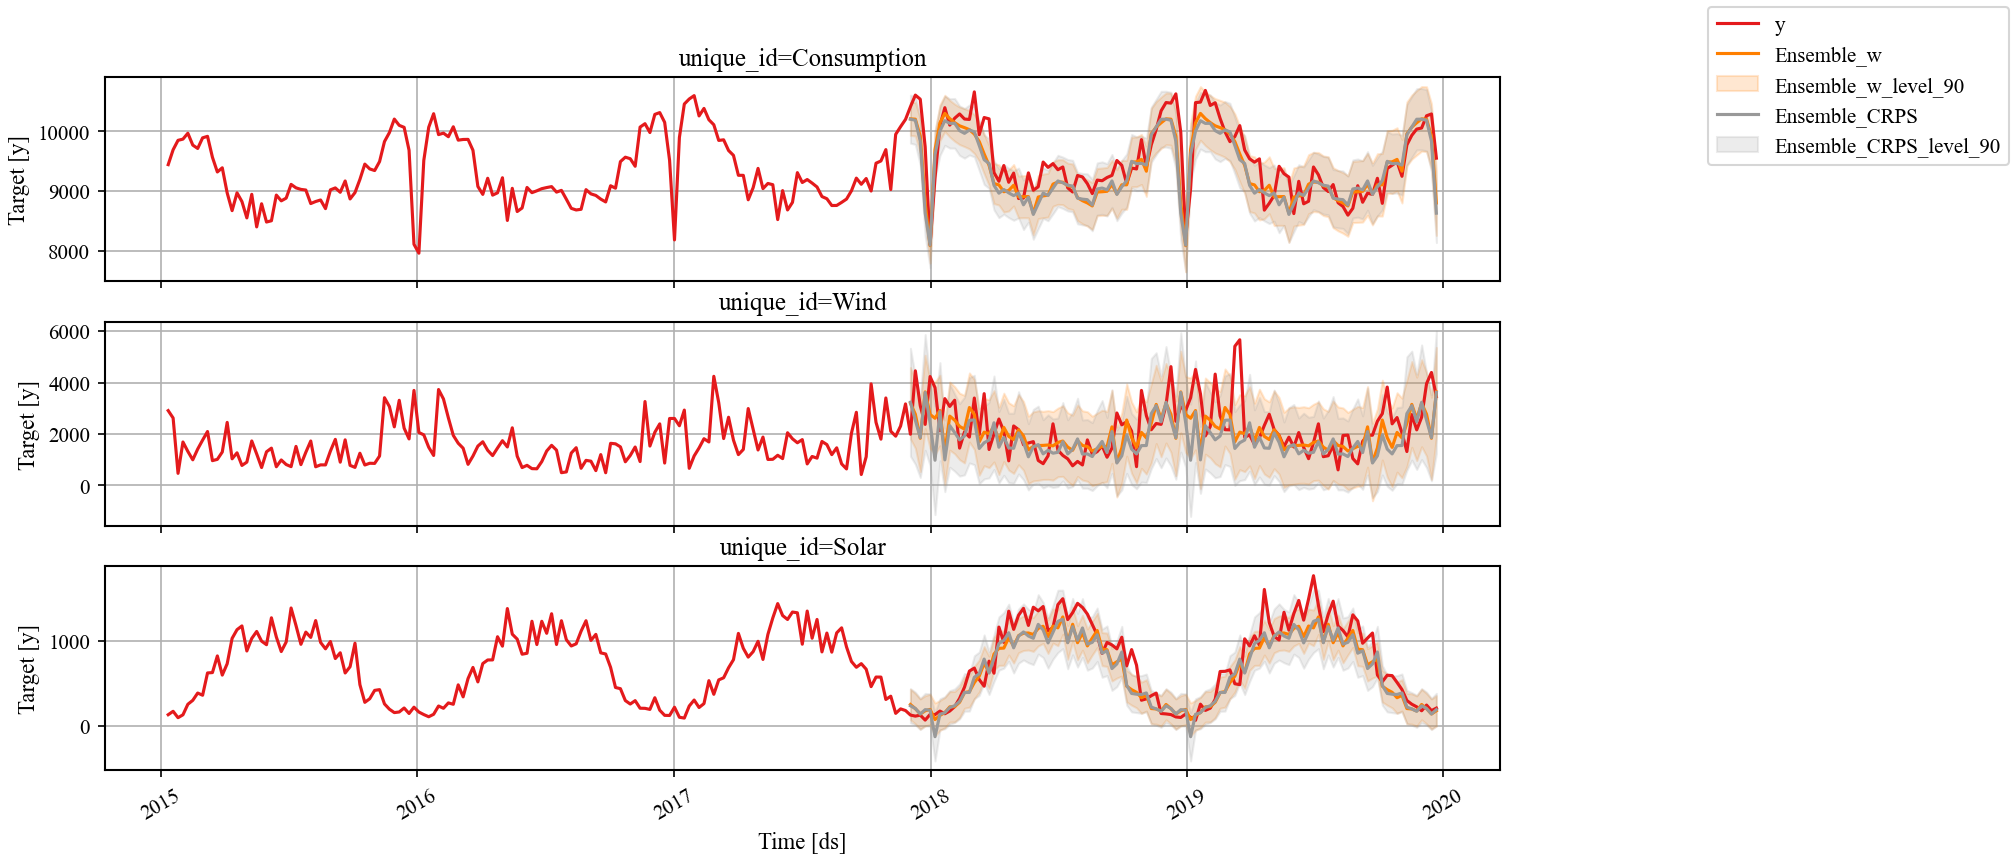

In [117]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

fcst_ensemble_  = vanilla_ensemble(
    forecasts_df=fcst_sf,
    aliases=aliases,
    levels=LEVELS,
    weights = weight_dict,
    ensemble_name = 'Ensemble_CRPS',
)

eval_sf = eval_sf.merge(fcst_ensemble_CI, on=['unique_id', 'ds'])

fcst_ensemble_  = vanilla_ensemble(
    forecasts_df=fcst_sf,
    aliases=aliases,
    levels=LEVELS,
    weights = weight_dict_,
    ensemble_name = 'Ensemble_w',
)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds']).merge(fcst_ensemble_, on=['unique_id', 'ds']).merge(fcst_ensemble_CI, on=['unique_id', 'ds'])


metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values= [*aliases, 'Ensemble_w', 'Ensemble_CRPS', ]
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    level=[90],
    models = ['Ensemble_w', 'Ensemble_CRPS', ],
    palette='Set1'
)


### Построение бустингов

#### Бустинг на тренд-сезонном разложении

##### Процедура 

- MSTL → тренд + сезонность (прогноз внутри процедуры)

- Остатки = y − (тренд + сезонность)

- ETS/ARIMA прогнозируют остатки

- Объеденение trend + seasonal + forecast_resid

##### Предсказание тренда и сезонности, для этого целисообразно использовать процедуру MSTL

Тренд и сезонность, полученные в результате будетм считать условно детерминированными.

In [283]:
models = [
    MSTL(season_length=SEASON, ),    
]
alias =models[0].alias

aliases = [model.alias for model in models]
LEVELS  = [90, 95]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS,
                      fitted = True # для in_sample
                     )

##### вычисление остатков in_sample (`fitted = True`)

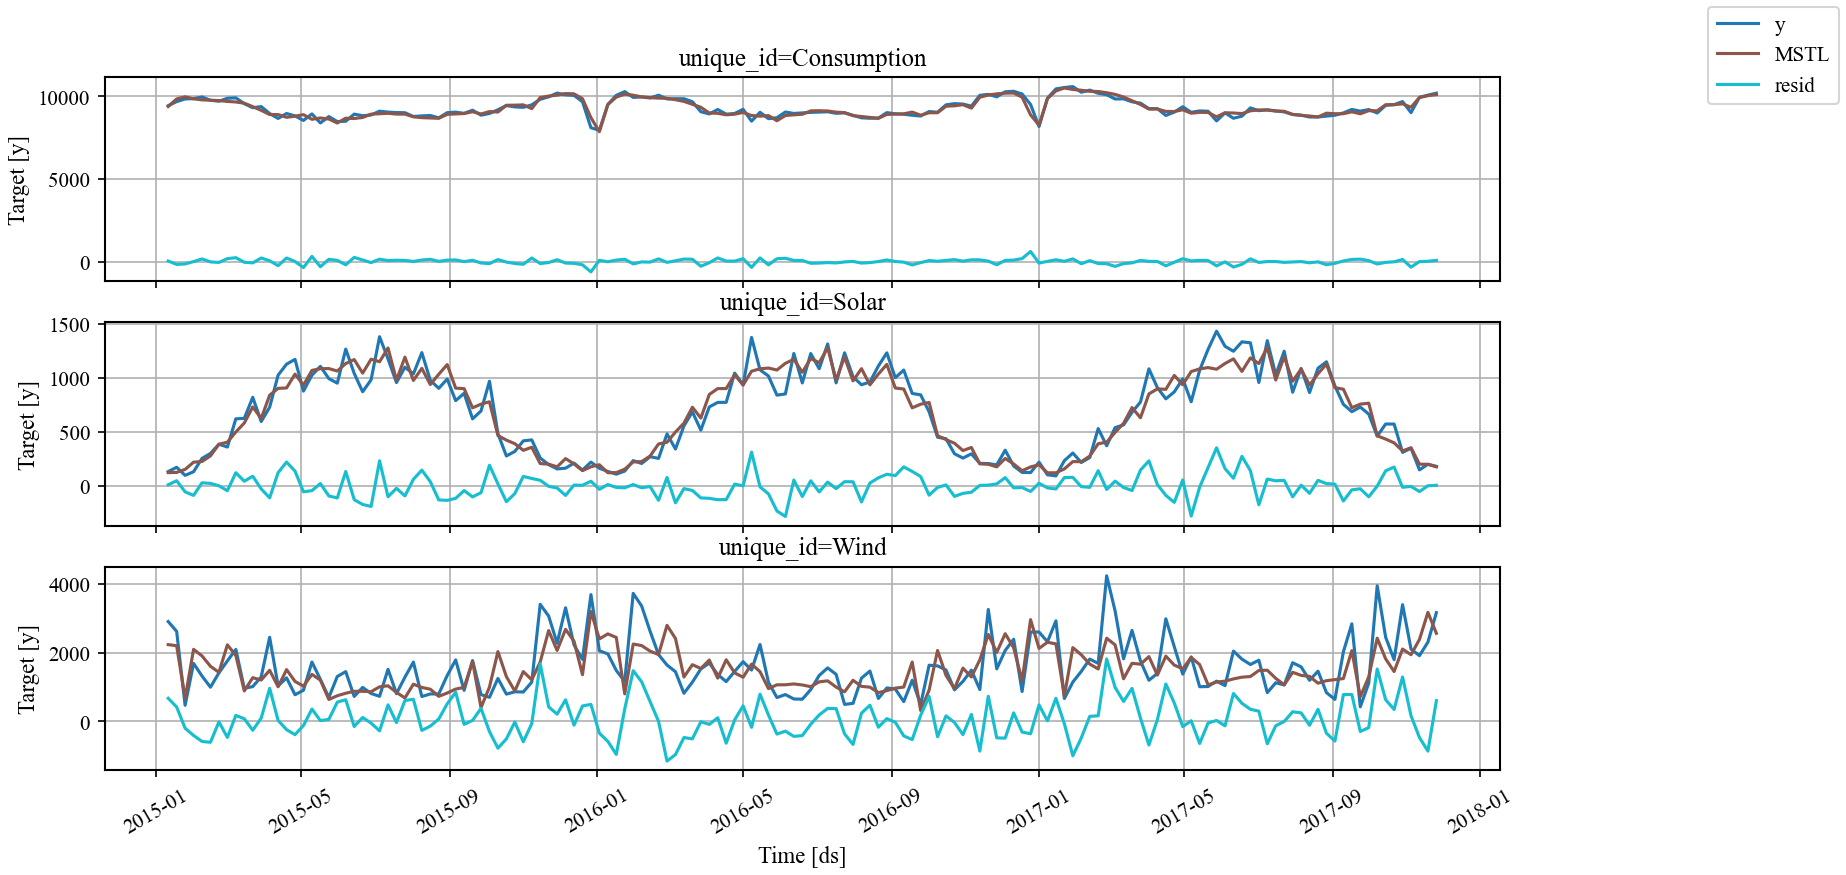

In [284]:
in_sample_sf = sf.forecast_fitted_values()
in_sample_sf['resid'] = in_sample_sf['y'] - in_sample_sf[alias]

plot_series_v2(forecasts_df=in_sample_sf)

##### предсказание остатков моделью `ETS`

In [288]:
resid_models = [
    AutoETS(model = 'ZZZ', alias='ETS_resid'),
]
resid_alias = resid_models[0].alias

sf_resid = StatsForecast(models=resid_models, freq=FREQ)
df_for_resid = in_sample_sf[['unique_id', 'ds', 'resid']].copy()
fcst_sf_resid = sf_resid.forecast(df=df_for_resid, 
                      h=FH, 
                      level=LEVELS,
                      target_col = 'resid',      
                      fitted = True,
                     )


##### Формирование итогового предсказания.

Обратите внимание, тут неопределенность считается только по остаткам! так как мы решили, что тренд и сезон детерминированы.

На самом деле неопределнность нужно калибровать или считать более правильным спсосбом (через бутстреп неопределенности)

In [292]:
fcst_sf[f'{alias}_r{resid_alias}'] = fcst_sf[alias]+fcst_sf_resid[resid_alias]
for lvl in LEVELS:
    fcst_sf[f'{alias}_r{resid_alias}-lo-{lvl}'] = fcst_sf[alias]+fcst_sf_resid[f'{resid_alias}-lo-{lvl}']
    fcst_sf[f'{alias}_r{resid_alias}-hi-{lvl}'] = fcst_sf[alias]+fcst_sf_resid[f'{resid_alias}-hi-{lvl}']  

##### Метрики

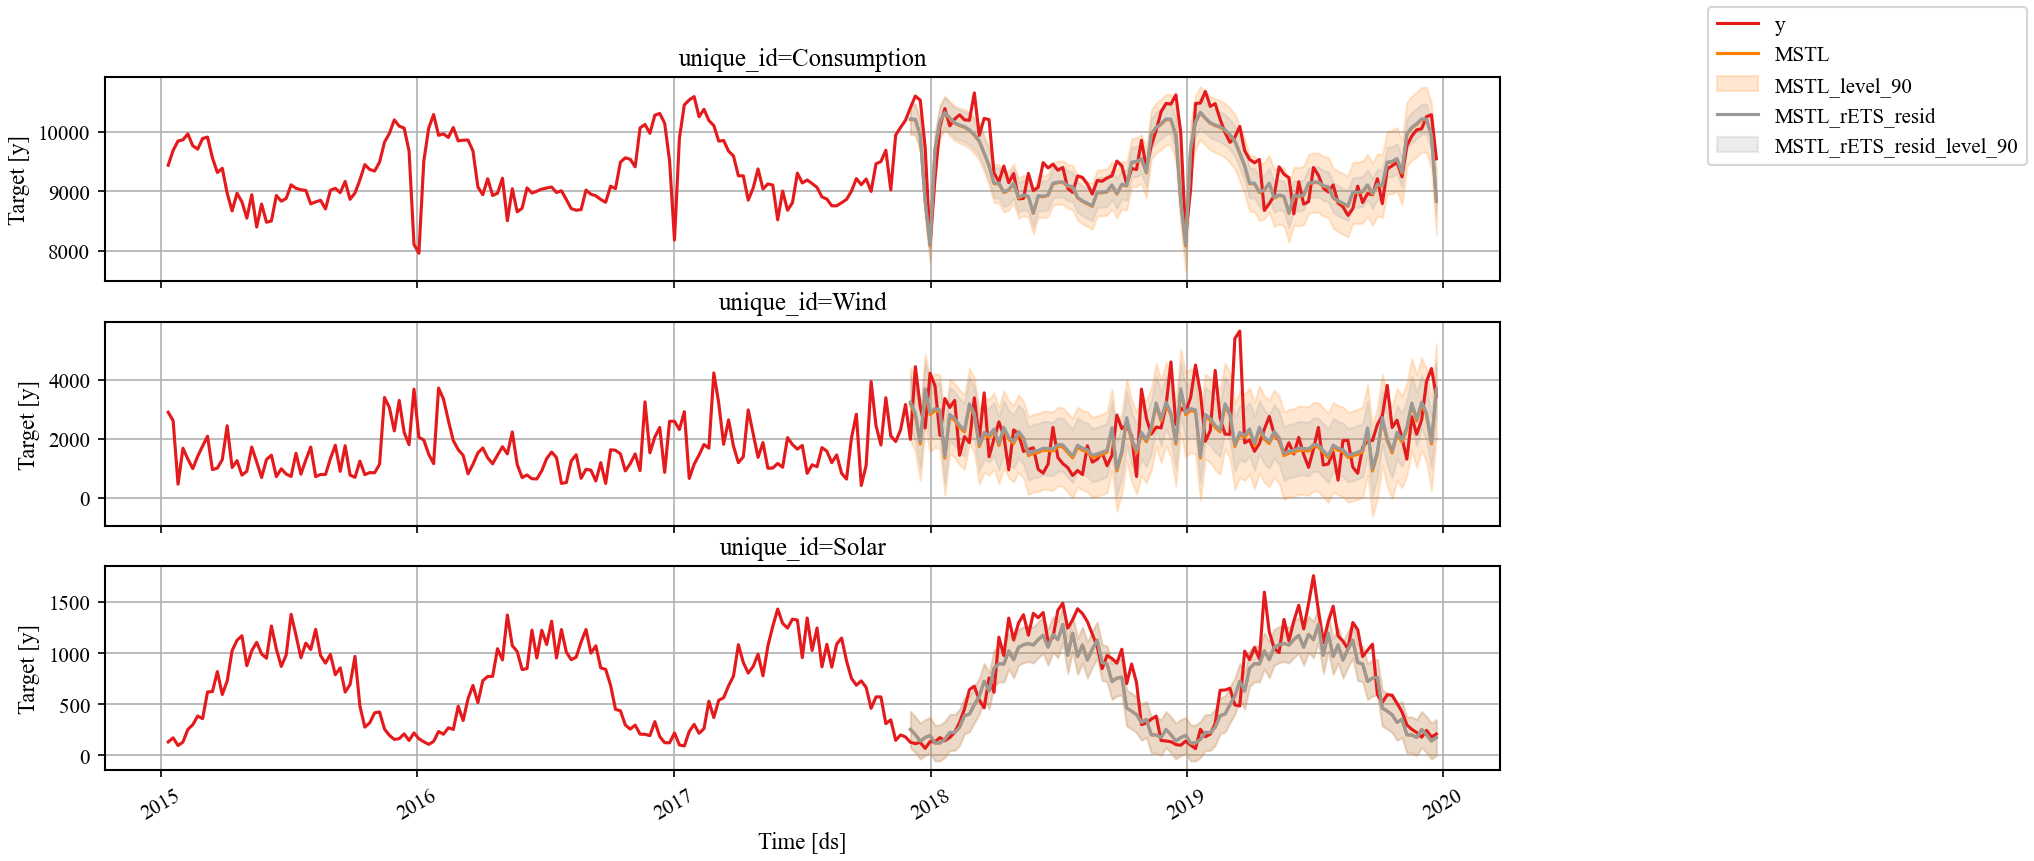

In [293]:
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics = metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values= [alias, f'{alias}_r{resid_alias}' ]
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[:1],
    palette='Set1',
)

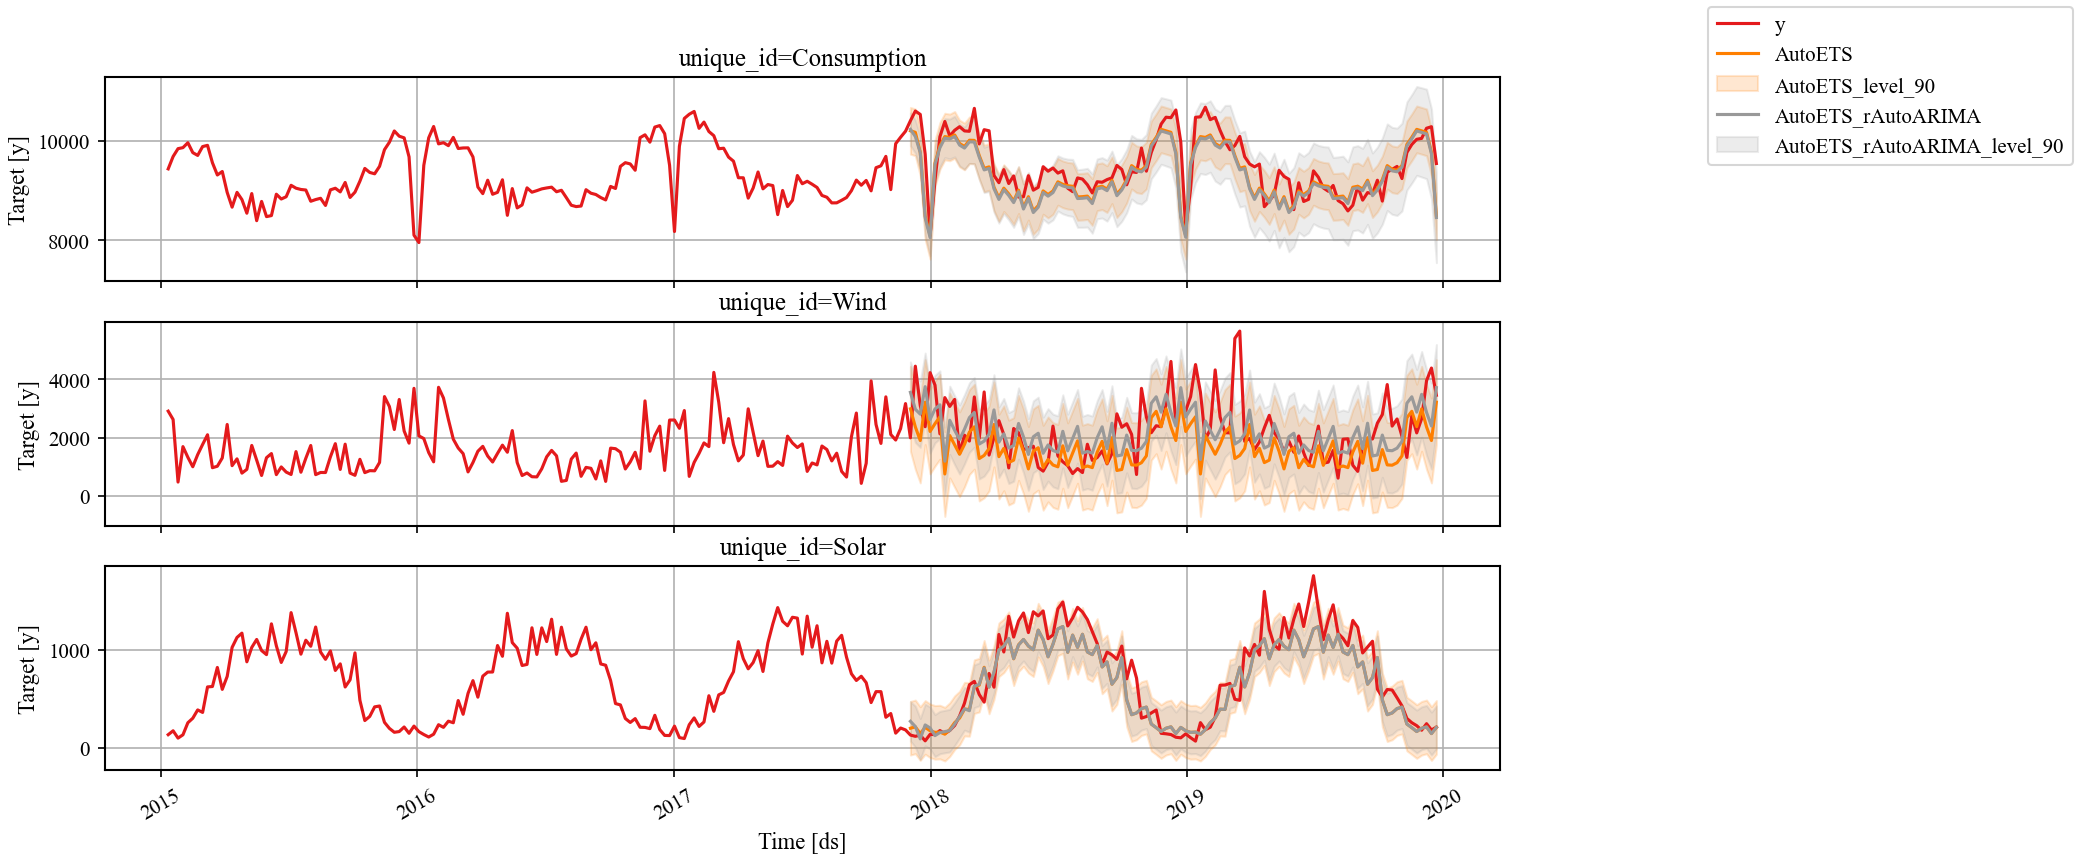

In [296]:
models = [
    AutoETS(season_length = SEASON, model = 'ZZA', )   
]
aliases = [model.alias for model in models]
LEVELS  = [90, 95]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS,
                      fitted = True # для in_sample
                     )

in_sample_sf = sf.forecast_fitted_values()
in_sample_sf['resid'] = in_sample_sf['y'] - in_sample_sf[aliases[0]]

resid_models = [
    AutoARIMA(season_length=SEASON),
]
resid_aliases = [model.alias for model in resid_models]

sf_resid = StatsForecast(models=resid_models, freq=FREQ)
df_for_resid = in_sample_sf[['unique_id', 'ds', 'resid']].copy()
fcst_sf_resid = sf_resid.forecast(df=df_for_resid, 
                      h=FH, 
                      level=LEVELS,
                      target_col = 'resid',      
                      fitted = True,
                     )


fcst_sf[f'{aliases[0]}_r{resid_aliases[0]}'] = fcst_sf[aliases[0]]+fcst_sf_resid[resid_aliases[0]]
in_sample_sf_resid = sf_resid.forecast_fitted_values()

in_sample_sf[f'{aliases[0]}_r{resid_aliases[0]}'] = in_sample_sf[aliases[0]]+in_sample_sf_resid[resid_aliases[0]]

for lvl in LEVELS:
    fcst_sf[f'{aliases[0]}_r{resid_aliases[0]}-lo-{lvl}'] = fcst_sf[aliases[0]]+fcst_sf_resid[f'{resid_aliases[0]}-lo-{lvl}']
    fcst_sf[f'{aliases[0]}_r{resid_aliases[0]}-hi-{lvl}'] = fcst_sf[aliases[0]]+fcst_sf_resid[f'{resid_aliases[0]}-hi-{lvl}']  

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics = metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values= [aliases[0], f'{aliases[0]}_r{resid_aliases[0]}' ]
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[:1],
    palette='Set1',
)

### Дополнительно

На самом деле приведенная выше оценка неопределенности - не точная. Для более правильной оценки нужно провести калибровку интервалов. Проведем эту процедуру методом блочного бутстрепа.

Корректная оценка интервалов прогноза достигается за счёт многократной генерации возможных будущих траекторий временного ряда. Для этого используется блочный бутстрэп остатков, позволяющий сохранить временную зависимость ошибок. Интервалы прогноза вычисляются как квантили распределения полученных траекторий.

In [297]:
import numpy as np
import pandas as pd

def block_bootstrap_forecast(
    in_sample_sf,       # in-sample прогноз: unique_id, ds, target_col, модели
    fcst_sf,            # предсказания на горизонте: unique_id, ds, модели
    target_col='y',
    models=None,
    levels=(90, 95),
    n_sim=5000,
    block_size=None,
    point_estimator='mean',  # 'mean', 'median', 'base'
    suffix='boot',
    use_model_sigma=False,   # если True, учитываем интервалы модели
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    fcst = fcst_sf.copy()
    
    if models is None:
        models = [c for c in in_sample_sf.columns if c not in ['unique_id','ds',target_col]]
    
    # --- вычисляем остатки in-sample ---
    resid_df = in_sample_sf[['unique_id', target_col] + models].copy()
    for m in models:
        resid = resid_df[target_col] - resid_df[m]
        resid_df[f'{m}_resid'] = resid - np.mean(resid)  # центровка
    
    # --- создаём колонки для bootstrap ---
    for m in models:
        fcst[f'{m}_{suffix}'] = np.nan
        for lvl in levels:
            fcst[f'{m}_{suffix}-lo-{lvl}'] = np.nan
            fcst[f'{m}_{suffix}-hi-{lvl}'] = np.nan
    
    # --- цикл по сериям и моделям ---
    for uid in fcst['unique_id'].unique():
        idx = fcst.index[fcst['unique_id']==uid]
        H = len(idx)
        
        for m in models:
            resid = resid_df.loc[resid_df['unique_id']==uid, f'{m}_resid'].dropna().values
            T = len(resid)
            
            if block_size is None:
                bs = max(2, min(int(np.sqrt(T)), H))
            else:
                bs = block_size
            
            max_start = T - bs + 1
            base_path = fcst.loc[idx, m].values.copy()
            
            # --- если учитываем sigma модели, прибавляем дисперсию ---
            if use_model_sigma:
                sigma_est = (fcst.loc[idx, f'{m}-hi-95'] - fcst.loc[idx, f'{m}-lo-95']) / 2
                sigma_est = sigma_est.fillna(0).values
            else:
                sigma_est = np.zeros(H)
            
            # --- симуляции ---
            sims = np.zeros((n_sim, H))
            for i in range(n_sim):
                eps = []
                while len(eps) < H:
                    start = rng.integers(0, max_start)
                    eps.extend(resid[start:start+bs])
                eps_arr = np.array(eps[:H])
                
                # добавляем модельную дисперсию
                noise = eps_arr + rng.normal(0, sigma_est)
                sims[i] = base_path + noise
            
            # --- точечный прогноз ---
            if point_estimator == 'mean':
                point_array = sims.mean(axis=0)
            elif point_estimator == 'median':
                point_array = np.quantile(sims, 0.5, axis=0)
            else:
                point_array = base_path
            
            fcst.loc[idx, f'{m}_{suffix}'] = point_array
            
            # --- интервалы ---
            for lvl in levels:
                alpha = (100 - lvl) / 2 / 100
                lo = np.quantile(sims, alpha, axis=0)
                hi = np.quantile(sims, 1 - alpha, axis=0)
                fcst.loc[idx, f'{m}_{suffix}-lo-{lvl}'] = lo
                fcst.loc[idx, f'{m}_{suffix}-hi-{lvl}'] = hi
    
    return fcst


In [304]:
fcst_sf = block_bootstrap_forecast(
    fcst_sf=fcst_sf,
    in_sample_sf=in_sample_sf,
    models = [aliases[0], f'{aliases[0]}_r{resid_aliases[0]}' ],
    levels=LEVELS,
    n_sim=30,          # можно 1000–3000
    block_size=SEASON,   # или None → auto
    point_estimator='median',
)


In [305]:
fcst_sf

,unique_id,ds,AutoETS,AutoETS-lo-95,AutoETS-lo-90,AutoETS-hi-90,AutoETS-hi-95,AutoETS_rAutoARIMA,AutoETS_rAutoARIMA-lo-90,AutoETS_rAutoARIMA-hi-90,...,AutoETS_boot,AutoETS_boot-lo-90,AutoETS_boot-hi-90,AutoETS_boot-lo-95,AutoETS_boot-hi-95,AutoETS_rAutoARIMA_boot,AutoETS_rAutoARIMA_boot-lo-90,AutoETS_rAutoARIMA_boot-hi-90,AutoETS_rAutoARIMA_boot-lo-95,AutoETS_rAutoARIMA_boot-hi-95
0,Consumption,2017-12-03,10206.349841,9646.654214,9736.638464,10676.061218,10766.045468,10236.567530,9907.731408,10565.403651,...,10134.965902,9993.271636,10386.371883,9909.745671,10407.868383,10229.735977,9736.156452,10339.196049,9682.514773,10411.132451
1,Consumption,2017-12-10,10175.226415,9615.526418,9705.511371,10644.941460,10734.926413,10091.217388,9760.462807,10421.971969,...,10099.021633,9988.190377,10443.375896,9943.847658,10496.327662,10086.653347,9944.507380,10467.574736,9905.268711,10472.783373
2,Consumption,2017-12-17,9773.563167,9213.858799,9303.844454,10243.281880,10333.267535,9765.622386,9432.957281,10098.287491,...,9688.502654,9519.065773,9984.271144,9478.595697,10008.939072,9738.189943,9341.583048,10094.124895,9297.992334,10121.735422
3,Consumption,2017-12-24,8492.824599,7933.115860,8023.102218,8962.546979,9052.533337,8458.074939,8097.398092,8818.751787,...,8429.147703,8339.154198,8710.486852,8330.131055,8757.282267,8455.077166,8316.161266,8743.690523,8296.820140,8782.075872
4,Consumption,2017-12-31,8095.506332,7535.793222,7625.780283,8565.232380,8655.219441,8057.531431,7693.721661,8421.341201,...,8017.083731,7805.267780,8397.374906,7732.544811,8508.012284,8054.945806,7786.155823,8261.540537,7747.458132,8318.223851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,Wind,2019-11-24,2375.501398,635.899039,915.581077,3835.421719,4115.103757,2874.416976,1402.664239,4346.169713,...,2178.556168,1395.658474,4261.155732,1240.157658,4644.264833,2943.374513,2256.744333,4405.266411,2051.180215,4706.950460
320,Wind,2019-12-01,2987.230540,1247.615025,1527.299178,4447.161902,4726.846055,3486.146117,2011.628959,4960.663275,...,2836.915318,2609.393400,4005.156437,2426.395341,4414.427154,3447.939011,2255.276157,4262.547583,2114.491925,4329.209117
321,Wind,2019-12-08,2365.183508,625.554838,905.241106,3825.125910,4104.812178,2864.099085,1386.822679,4341.375491,...,2198.588084,1837.570249,3498.480692,1710.723345,4085.962723,2893.611690,2231.223262,3806.926961,2013.994890,4007.535820
322,Wind,2019-12-15,1898.084202,158.442377,438.130760,3358.037645,3637.726028,2396.999779,916.969270,3877.030289,...,1721.660225,982.165919,2879.847690,719.663617,3320.261594,2217.594035,1141.749985,3263.369565,1137.139803,3416.186128


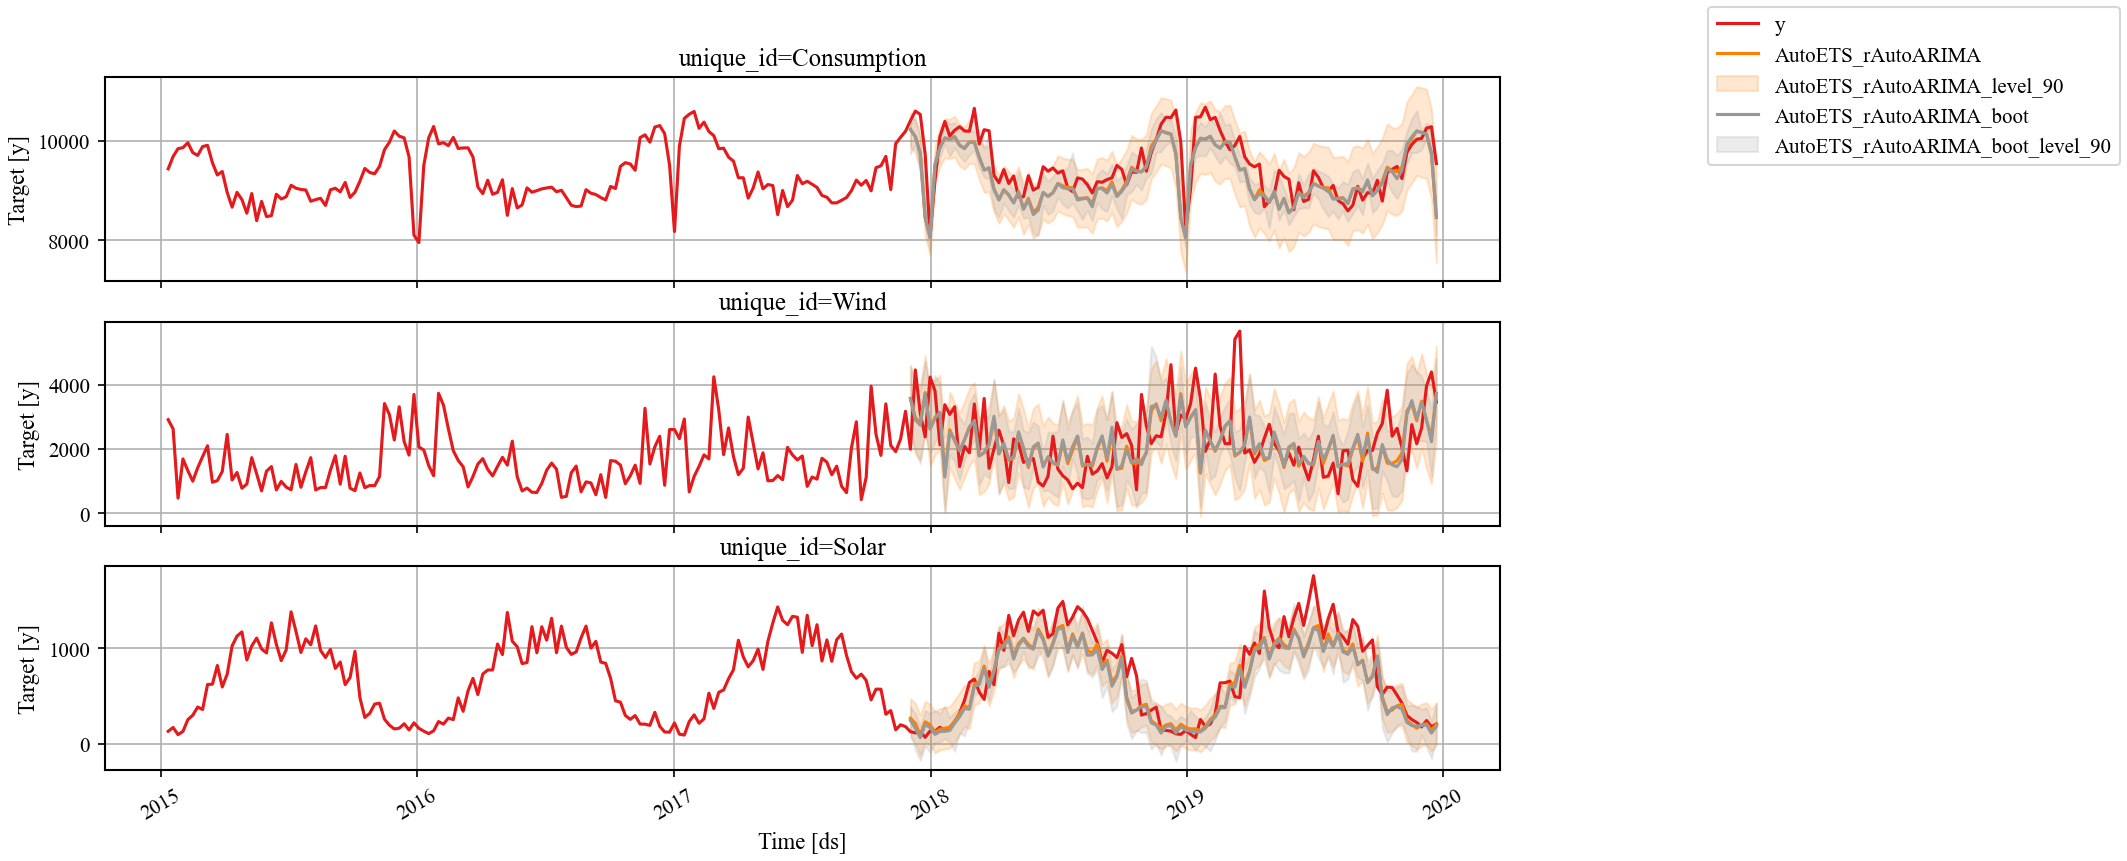

In [306]:
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics = metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values= [f'{aliases[0]}_r{resid_aliases[0]}', f'{aliases[0]}_r{resid_aliases[0]}_boot' ]
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[:1],
    models = [f'{aliases[0]}_r{resid_aliases[0]}', f'{aliases[0]}_r{resid_aliases[0]}_boot' ],
    palette='Set1',
)

## Обнаружение аномальных данных

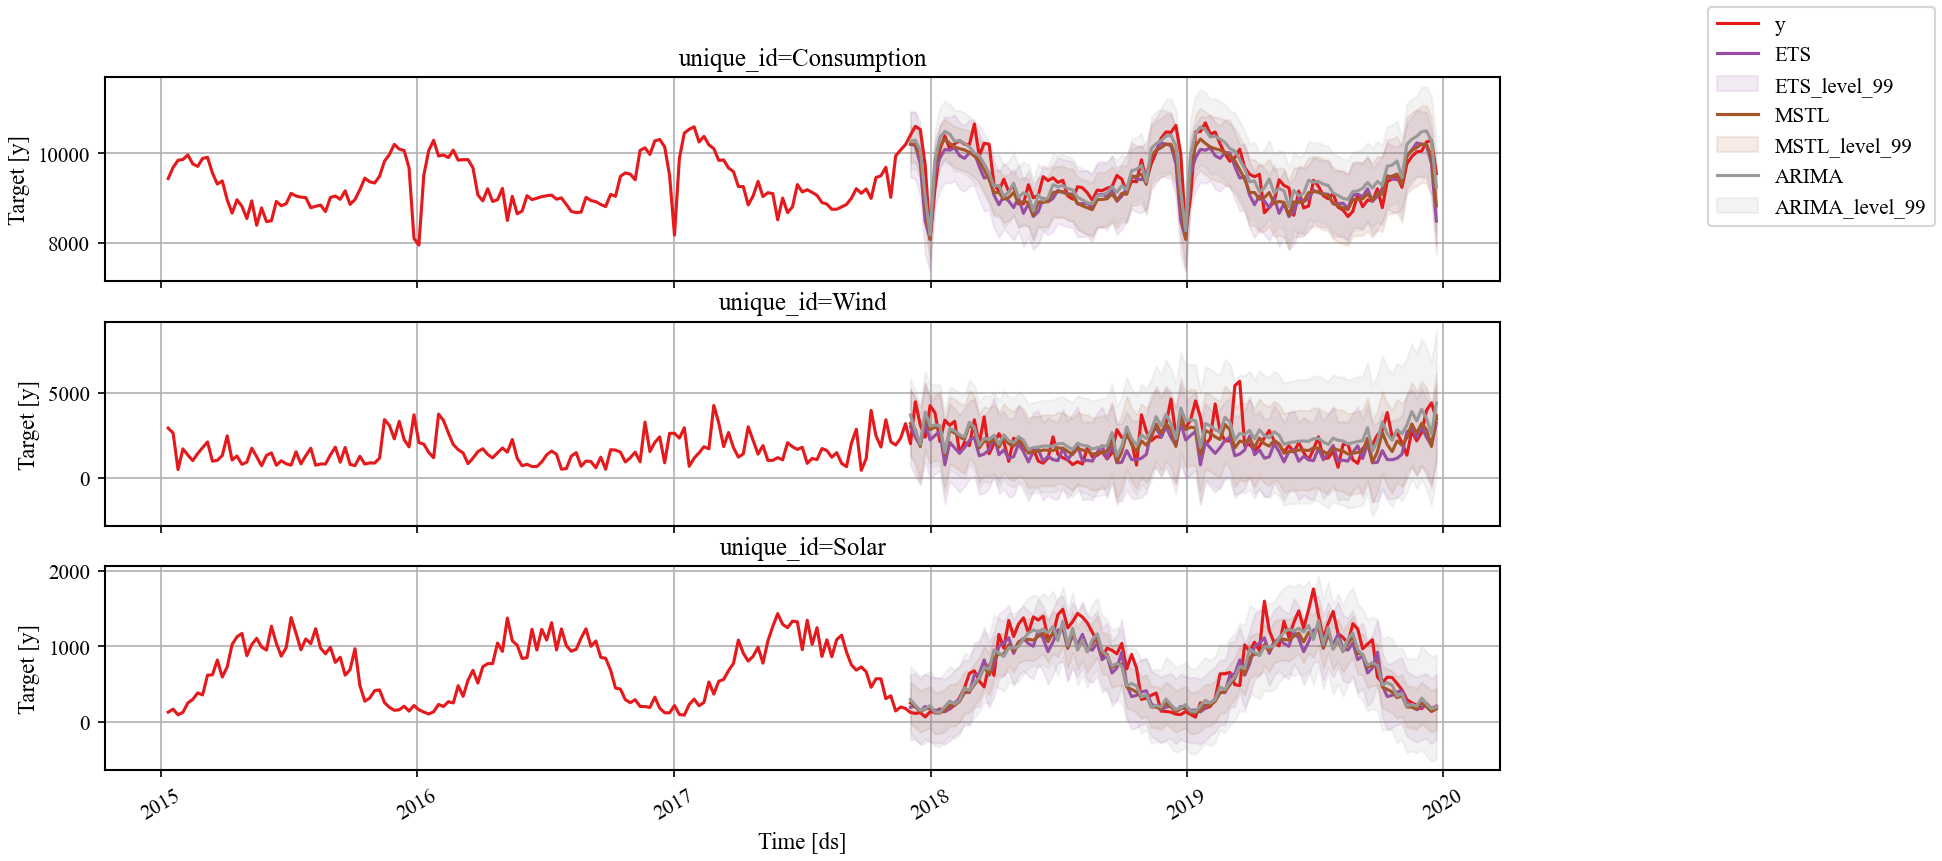

In [40]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),
    ARIMA(order=(3, 1, 1),
                season_length = SEASON,
                seasonal_order = (0, 1, 1,)  )
    
]
aliases = [model.alias for model in models]
LEVELS = [95, 99]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS,
                      fitted=True
                     )
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

plot_series_v2(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[-1:],
    palette='Set1',
)

In [41]:
insample_forecasts = sf.forecast_fitted_values()
# insample_forecasts.head()

,unique_id,ds,y,ETS,ETS-lo-99,ETS-lo-95,ETS-hi-95,ETS-hi-99,MSTL,MSTL-lo-99,MSTL-lo-95,MSTL-hi-95,MSTL-hi-99,ARIMA,ARIMA-lo-99,ARIMA-lo-95,ARIMA-hi-95,ARIMA-hi-99
0,Consumption,2015-01-11,9440.105,9532.139116,8802.593987,8977.023847,10087.254386,10261.684245,9393.007101,8997.231693,9091.859217,9694.154986,9788.782509,9434.654755,8811.070771,8960.165957,9909.143553,10058.238739
1,Consumption,2015-01-18,9689.010,9859.492653,9129.947524,9304.377383,10414.607922,10589.037782,9849.421070,9453.645663,9548.273186,10150.568955,10245.196478,9686.379775,9062.795791,9211.890977,10160.868573,10309.963759
2,Consumption,2015-01-25,9847.035,10052.036055,9322.490926,9496.920785,10607.151324,10781.581184,9976.629985,9580.854577,9675.482100,10277.777869,10372.405392,9845.179557,9221.595573,9370.690759,10319.668355,10468.763541
3,Consumption,2015-02-01,9867.317,10046.977680,9317.432551,9491.862411,10602.092950,10776.522809,9855.569323,9459.793916,9554.421439,10156.717208,10251.344731,9865.916149,9242.332165,9391.427351,10340.404947,10489.500133
4,Consumption,2015-02-08,9966.415,10119.065500,9389.520371,9563.950230,10674.180769,10848.610629,9793.641430,9397.866023,9492.493546,10094.789315,10189.416838,9965.207870,9341.623886,9490.719072,10439.696668,10588.791854


In [42]:
anomalies = insample_forecasts[~insample_forecasts['y'].between(insample_forecasts['MSTL-lo-99'], insample_forecasts['MSTL-hi-99'])]
# anomalies.head()

,unique_id,ds,y,ETS,ETS-lo-99,ETS-lo-95,ETS-hi-95,ETS-hi-99,MSTL,MSTL-lo-99,MSTL-lo-95,MSTL-hi-95,MSTL-hi-99,ARIMA,ARIMA-lo-99,ARIMA-lo-95,ARIMA-hi-95,ARIMA-hi-99
50,Consumption,2015-12-27,8106.565,8427.462187,7697.917058,7872.346918,8982.577457,9157.007316,8717.428300,8321.652892,8416.280416,9018.576184,9113.203708,8107.600383,7484.016399,7633.111585,8582.089181,8731.184367
102,Consumption,2016-12-25,9513.222,8413.579660,7684.034531,7858.464390,8968.694929,9143.124789,8891.184984,8495.409576,8590.037100,9192.332868,9286.960392,8357.197688,7733.613704,7882.708890,8831.686486,8980.781672
220,Solar,2016-05-08,1374.571,1043.070941,616.962855,718.842739,1367.299143,1469.179028,1062.014713,787.897400,853.437203,1270.592222,1336.132025,1053.171974,624.729955,727.167869,1379.176079,1481.613993
224,Solar,2016-06-05,851.244,1208.413380,782.305294,884.185179,1532.641582,1634.521467,1134.713967,860.596654,926.136457,1343.291476,1408.831279,1165.292997,736.850978,839.288892,1491.297102,1593.735015
272,Solar,2017-05-07,779.076,1061.664269,635.556182,737.436067,1385.892470,1487.772355,1058.985417,784.868105,850.407908,1267.562926,1333.102730,1308.513101,880.071083,982.508997,1634.517206,1736.955120


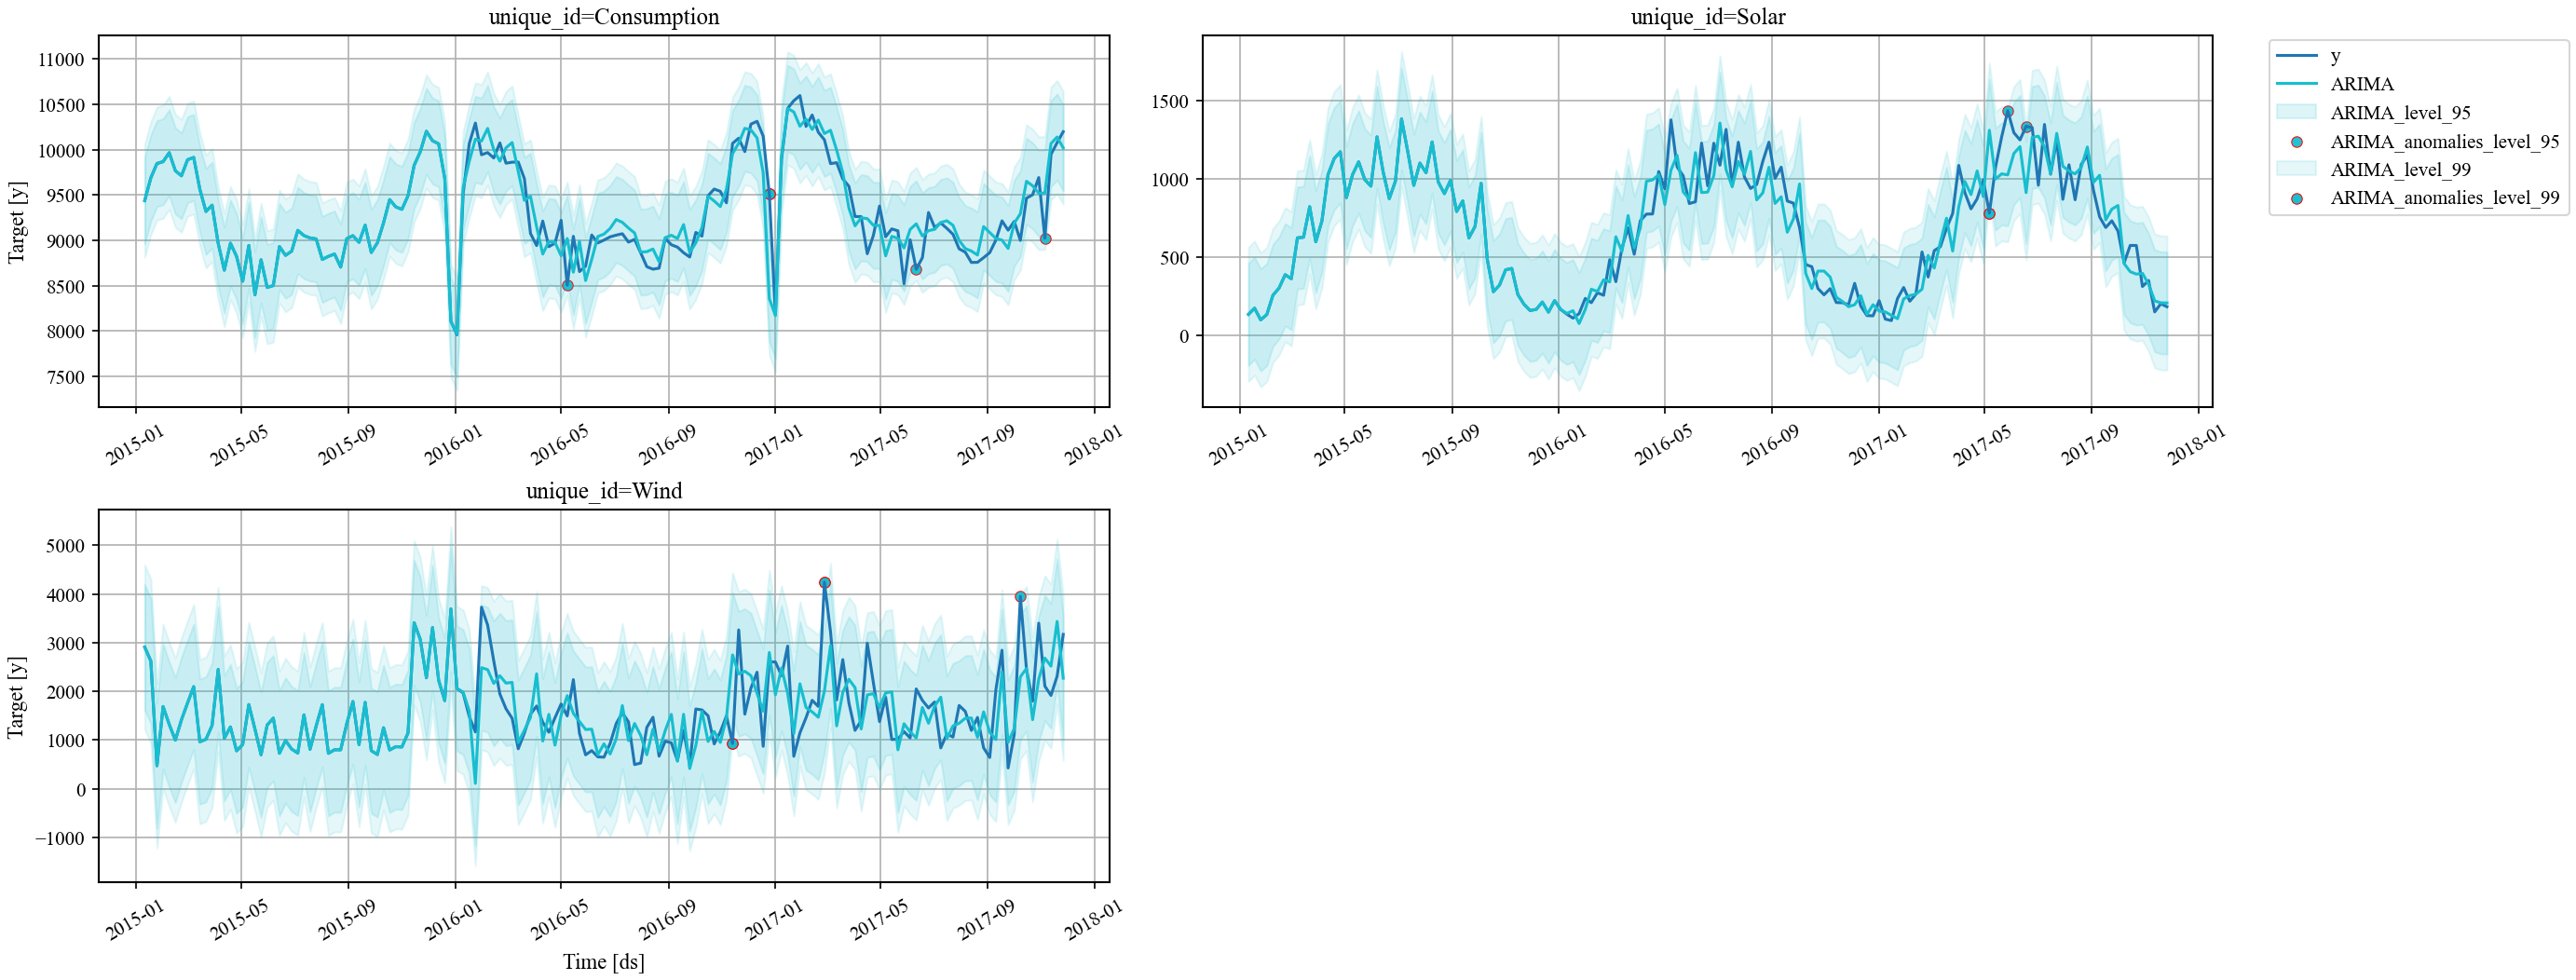

In [45]:
plot_series(forecasts_df=insample_forecasts,
            models = ['ARIMA'],
            level=LEVELS, 
            plot_anomalies=True)

## ДОПОЛНИТЕЛЬНО

### некоторые аугментации искажением

In [ ]:
df_addtitive_shock = add_additive_shock(
    df_train,
    shock_date='2015-03-01',
    shock_strength=1.5,   # 1.5 * IQR — сильный шок
    recovery_offset='12W',   # 12 недель восстановления
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_addtitive_shock, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_seasonal_imbalance_by_quantile(
    df_train,
    target_seasonal_phases=list(range(20,32)),   # летние недели
    season_length=SEASON,
    imbalance_percent=45.0,
    direction='reduce',
    start_date='2015-01-01',
    duration_offset='2Y', 
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_local_volatility_spike(
    df_train,
    spike_start='2015-04-01',
    duration_offset='16W',
    noise_percent=50.0,
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result =  add_asymmetric_shock(
    df_train,
    shock_start='2015-03-01',
    recovery_offset='12W',
     drop_percent=40.0,
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_signal_degradation(
    df_train,
    degradation_start='2015-01-01',
    duration_offset='52W',      # ← offset-строка вместо weeks
    final_snr_ratio=0.1,
    freq=FREQ,                  # ← обязательная частота
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_seasonal_phase_shift(
    df_train,
    phase_shift_steps=4,
    season_length=SEASON,          # используется только для документации
    start_date='2015-01-01',
    duration_offset='1Y',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_trend_break(
    df_train,
    break_date='2016-01-01',
    trend_change_per_step=-33.5,
    duration_offset='1Y',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
holidays = [
    '2016-10-24', '2016-10-25', '2016-10-26',
    '2017-10-24', '2017-10-25', '2017-10-26',
    '2018-10-24', '2018-10-25', '2018-10-26',
    '2019-10-24', '2019-10-25', '2019-10-26',
]

df_result = add_seasonal_regressors_effect(
    df_train,
    event_dates=holidays,
    effect_percent=65.0,
    direction='spike',        # снижение активности
    window_radius=4,        # включая день до и после
    freq=FREQ,
    reference='pre_event'
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_sensor_drift(
    df_train,
    drift_start='2016-01-01',
    duration_offset='1Y',
    drift_percent=65.0,
    profile='saturation',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_distribution_shift(df_train, 
                                shift_start='2016-04-01', 
                                shift_percent=35.0, 
                                stat='median', 
                                freq=FREQ)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_variance_expansion(df_train, 
                                expansion_start='2016-04-01', 
                                   duration_offset='1Y',
                                expansion_factor=2.5,
                                freq=FREQ)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_skewness_shift(df_train, 
                                skew_start='2016-04-01', 
                                   duration_offset='1Y',
tail='right',              # 'right' или 'left'
    intensity=2.3,             # сила искажения (0–1)
                                freq=FREQ)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

####  ЕЩЕ Беггинг

In [ ]:
import numpy as np
import pandas as pd
from typing import List

def bagging_forecast(
    sf,
    df_train: pd.DataFrame,
    h: int,
    level: List[int],
    n_bags: int = 10,
    window_size: int = None,
    min_train_length: int = 52,
    id_col: str = 'unique_id',
    time_col: str = 'ds',
    target_col: str = 'y'
) -> pd.DataFrame:
    """
    Бэггинг через скользящие окна с использованием готового StatsForecast.
    
    Возвращает DataFrame с колонками:
        <model_alias>_bagged, <model_alias>_bagged-lo-X, <model_alias>_bagged-hi-X
    """
    # Получаем alias моделей из sf
    model_aliases = [getattr(m, 'alias', type(m).__name__) for m in sf.models]
    
    all_uids = df_train[id_col].unique()
    total_points_per_series = len(df_train) // len(all_uids)
    
    if window_size is None:
        window_size = max(min_train_length, total_points_per_series - 26)
    
    bag_forecasts = []
    
    for i in range(n_bags):
        # Случайное окно: сдвиг начала
        max_start = total_points_per_series - window_size
        if max_start <= 0:
            start_idx = 0
        else:
            start_idx = np.random.randint(0, max_start + 1)
        
        # Выбираем последние N точек после start_idx
        df_bag = df_train.groupby(id_col).apply(
            lambda x: x.iloc[start_idx:start_idx + window_size]
        ).reset_index(drop=True)
        
        if len(df_bag) < len(all_uids) * min_train_length:
            continue
        
        try:
            fcst = sf.forecast(df=df_bag, h=h, level=level)
            # Переименовываем колонки: добавляем _bag_i
            rename_map = {}
            for alias in model_aliases:
                rename_map[alias] = f"{alias}_bag_{i}"
                for l in level:
                    lo_key = f"{alias}-lo-{l}"
                    hi_key = f"{alias}-hi-{l}"
                    if lo_key in fcst.columns:
                        rename_map[lo_key] = f"{alias}_bag_{i}-lo-{l}"
                    if hi_key in fcst.columns:
                        rename_map[hi_key] = f"{alias}_bag_{i}-hi-{l}"
            fcst = fcst.rename(columns=rename_map)
            bag_forecasts.append(fcst)
        except Exception as e:
            print(f"Bag {i} failed: {e}")
            continue
    
    if not bag_forecasts:
        raise RuntimeError("No successful bags")
    
    # Объединяем все бэги
    merged = bag_forecasts[0]
    for fcst in bag_forecasts[1:]:
        merged = merged.merge(fcst, on=['unique_id', 'ds'], how='outer')
    
    # Финальный результат
    result = merged[['unique_id', 'ds']].copy()
    
    # Для каждой модели — агрегируем по бэгам
    for alias in model_aliases:
        # Точечные прогнозы
        point_cols = [f"{alias}_bag_{i}" for i in range(len(bag_forecasts)) 
                      if f"{alias}_bag_{i}" in merged.columns]
        if point_cols:
            result[f"{alias}_bagged"] = merged[point_cols].median(axis=1)
        
        # Интервалы
        for l in level:
            lo_cols = [f"{alias}_bag_{i}-lo-{l}" for i in range(len(bag_forecasts)) 
                       if f"{alias}_bag_{i}-lo-{l}" in merged.columns]
            hi_cols = [f"{alias}_bag_{i}-hi-{l}" for i in range(len(bag_forecasts)) 
                       if f"{alias}_bag_{i}-hi-{l}" in merged.columns]
            if lo_cols:
                result[f"{alias}_bagged-lo-{l}"] = merged[lo_cols].median(axis=1)
            if hi_cols:
                result[f"{alias}_bagged-hi-{l}"] = merged[hi_cols].median(axis=1)
    
    return result

In [ ]:
# У вас уже есть:
# sf = StatsForecast(models=[...], freq=FREQ)

# Запуск бэггинга
fcst_bagged = bagging_forecast(
    sf=sf,
    df_train=df_train,
    h=FH,
    level=[90],
    n_bags=5,
    window_size=2*SEASON,  # ~2 года
    min_train_length=SEASON
)

 

# Оценка
eval_bagged = df_test.merge(fcst_bagged, on=['unique_id', 'ds'])
metrics_bagged = evaluate(
    df=eval_bagged,
    metrics=metrics,
    train_df=df_train,
    level=[90]
)
metrics_bagged

In [ ]:
# Визуализация для MSTL
plot_series_v2(
    df_train,
    forecasts_df=fcst_bagged,
    level=[90]
)


In [241]:
import session_info
session_info.show(html=False)

-----
TSC_Nixtla_augmentation     NA
TSC_Nixtla_dump             NA
matplotlib                  3.9.4
numpy                       1.26.4
pandas                      2.3.2
pmdarima                    2.0.4
scipy                       1.13.1
session_info                v1.0.1
sklearn                     1.6.1
statsforecast               2.0.3
statsmodels                 0.14.5
utilsforecast               0.2.14
-----
IPython             8.18.1
jupyter_client      8.6.3
jupyter_core        5.8.1
jupyterlab          4.4.6
notebook            7.4.5
-----
Python 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
Windows-10-10.0.19045-SP0
-----
Session information updated at 2026-01-28 19:52
